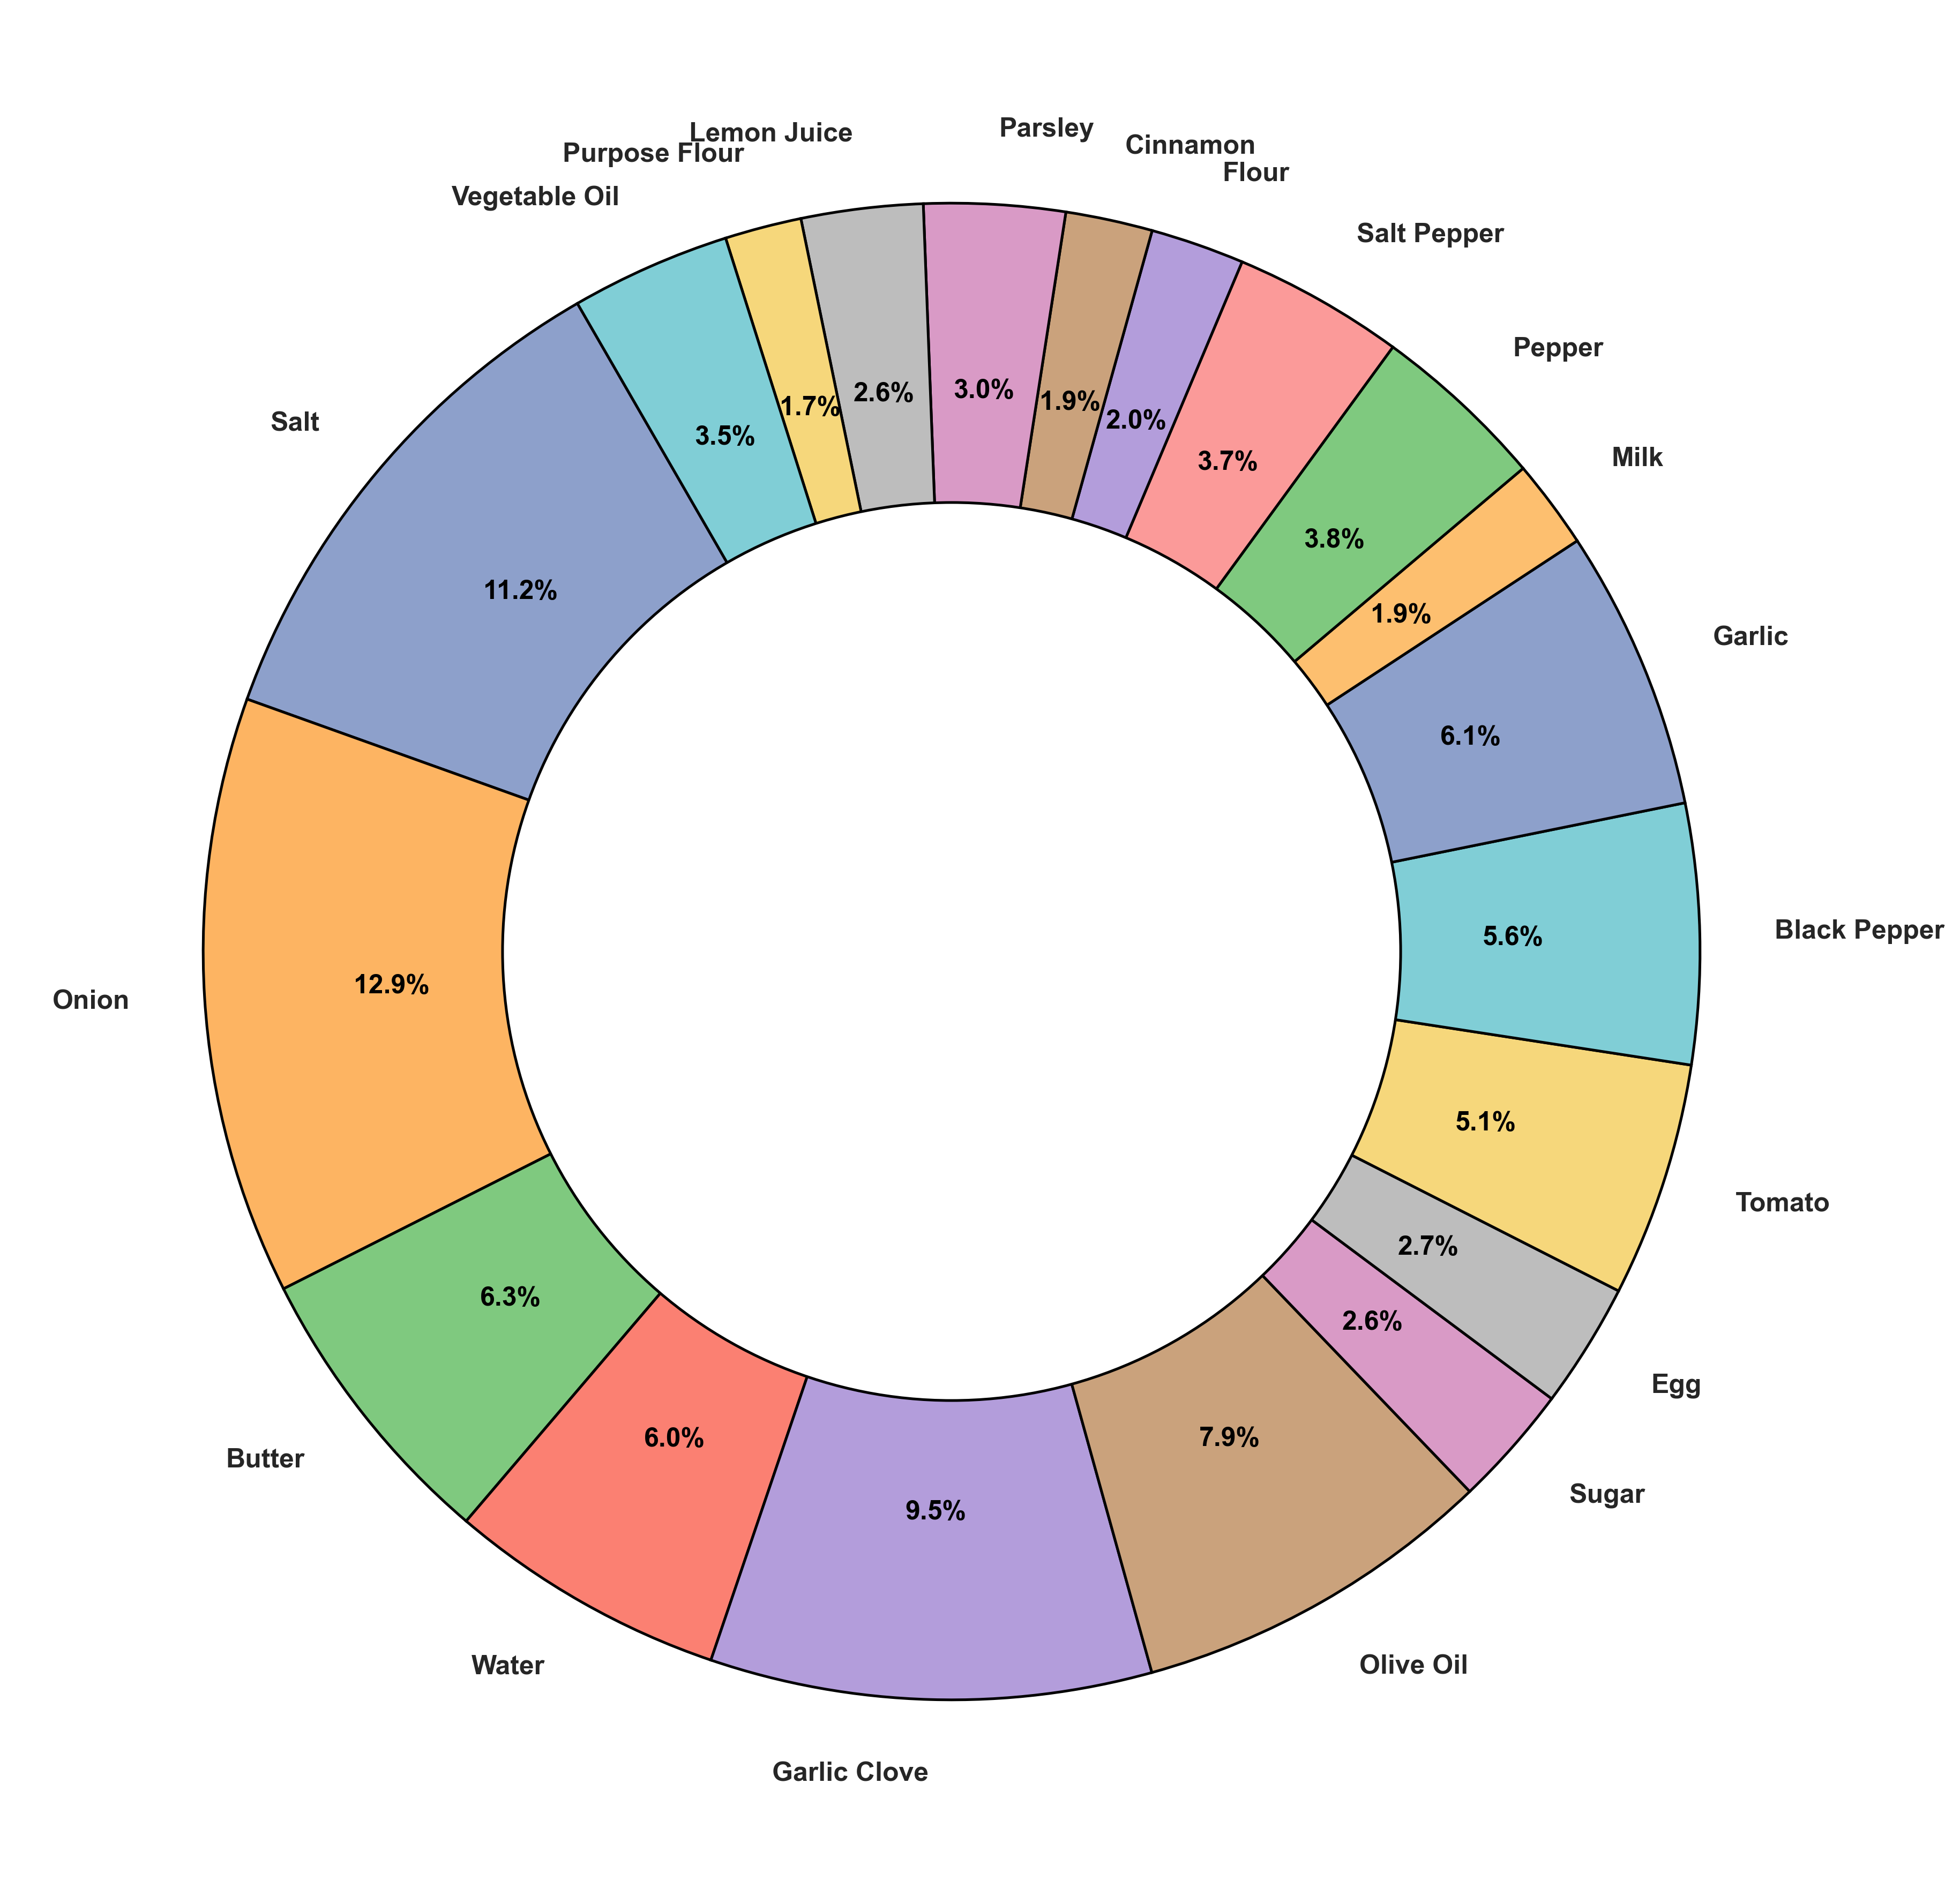

In [175]:
import pandas as pd
import matplotlib.pyplot as plt

# Load
df = pd.read_csv(r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Ingredient_Category.csv")

# Clean
df.columns = df.columns.str.strip()
df['ingredient'] = df['ingredient'].str.strip().str.title()

# Order
order = [
    'Salt', 'Onion', 'Butter', 'Water', 'Garlic Clove', 'Olive Oil',
    'Sugar', 'Egg', 'Tomato', 'Black Pepper', 'Garlic', 'Milk',
    'Pepper', 'Salt Pepper', 'Flour', 'Cinnamon', 'Parsley',
    'Lemon Juice', 'Purpose Flour', 'Vegetable Oil'
]

# Match + reorder
df = df.set_index('ingredient')
df = df[df.index.isin(order)]
df = df.reindex(order).dropna().reset_index()

# Colors
colors = [
    '#8da0cb','#fdb462','#7fc97f','#fb8072','#b39ddb','#caa27c',
    '#d99ac6','#bdbdbd','#f6d77b','#80ced6','#8da0cb','#fdbf6f',
    '#7fc97f','#fb9a99','#b39ddb','#caa27c','#d99ac6','#bdbdbd',
    '#f6d77b','#80ced6'
]

# Plot
plt.figure(figsize=(13, 12), dpi=300)

wedges, texts, autotexts = plt.pie(
    df['frequency'],
    labels=df['ingredient'],
    autopct='%1.1f%%',
    startangle=120,
    colors=colors[:len(df)],
    wedgeprops={
        'edgecolor': 'black',
        'linewidth': 1.2   # 🔥 thicker border (visible inside + outside)
    },
    pctdistance=0.75,      # 🔥 move % inside donut ring
    labeldistance=1.1,
    textprops={'fontsize': 12, 'fontweight': 'bold'}
)

# Doughnut hole
centre_circle = plt.Circle((0, 0), 0.60, fc='white', edgecolor='black', linewidth=1.2)
plt.gca().add_artist(centre_circle)

# 🔥 Style percentage text
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')

# Save
plt.tight_layout()
plt.savefig("recipedb_ingredient_doughnut_Light_color.png", dpi=300, bbox_inches="tight")

plt.show()

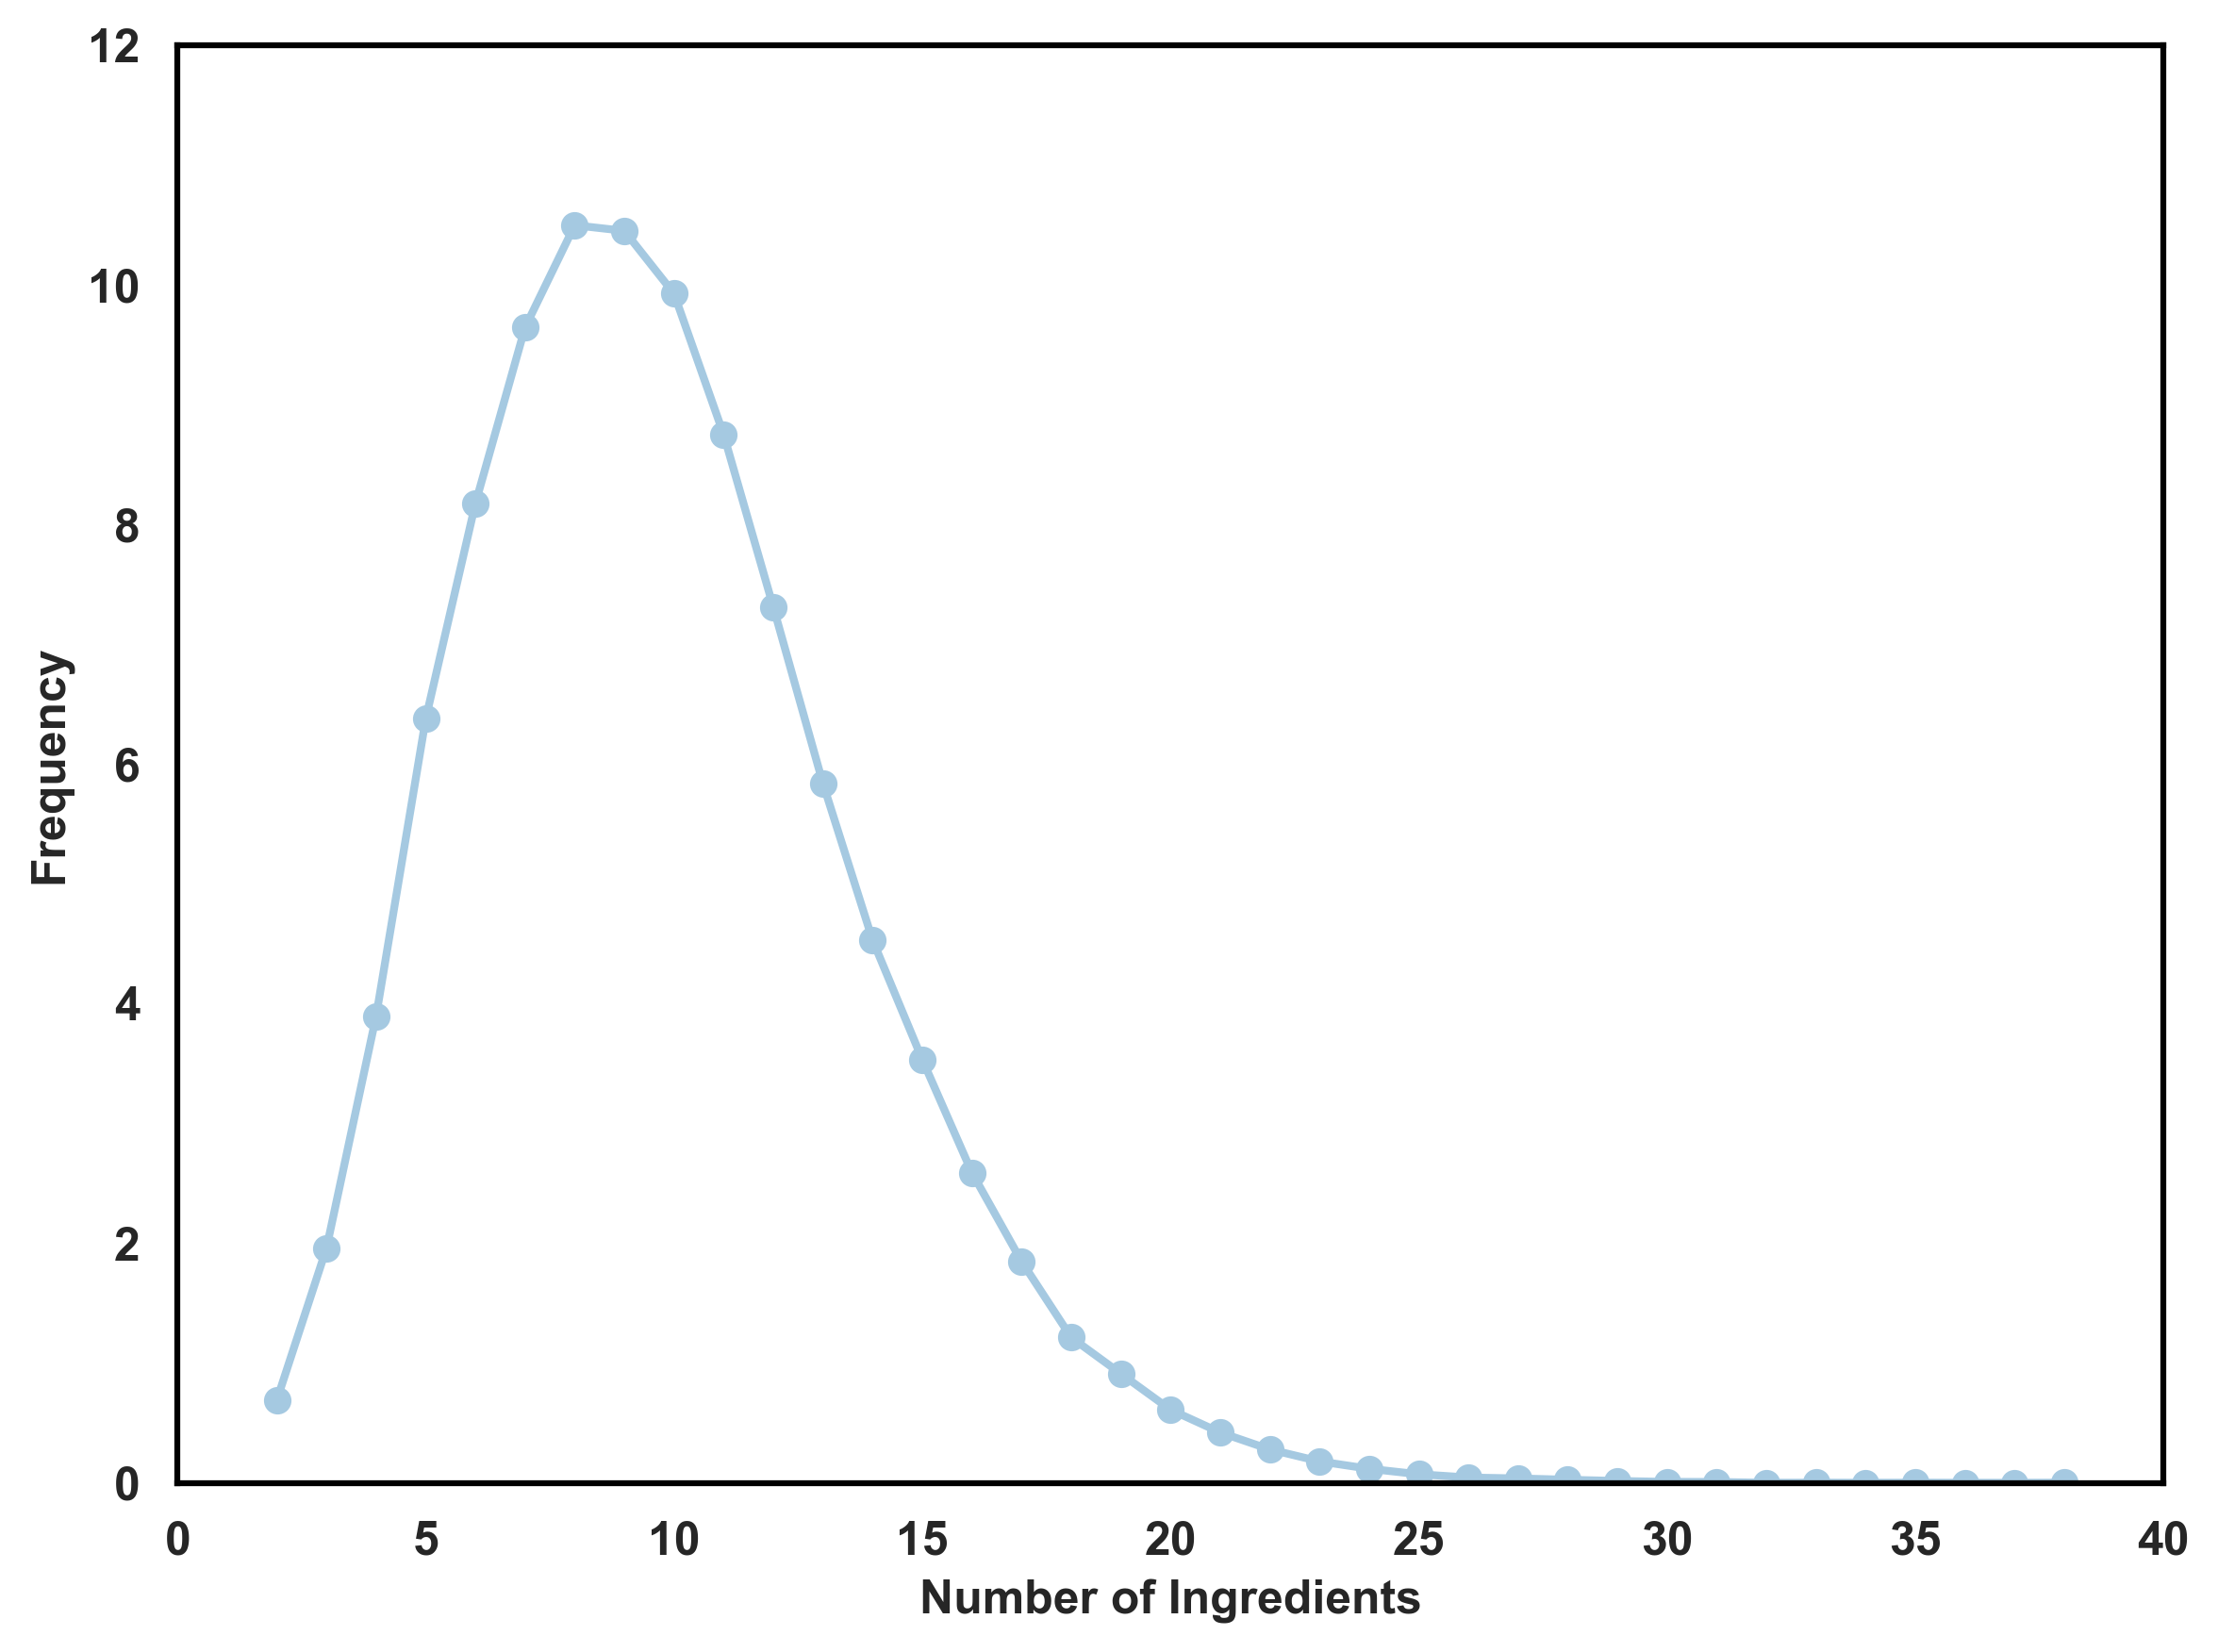

✅ Saved: C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git\ingredient_recipe_size_distribution_Light_color.png | Avg recipe size = 10


In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as mcolors

# =========================
# 🎨 Function to lighten color
# =========================
def lighten_color(color, amount=0.6):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - np.array(c)) * (1 - amount))

# =========================
# 📂 Load YOUR FILE
# =========================
file_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Recipe_Ingredient_Phrases.csv"
output_dir = os.path.dirname(file_path)

df = pd.read_csv(file_path)

# =========================
# 🧹 Clean
# =========================
df.columns = df.columns.str.strip()
df['Ingredient_Phrases'] = df['Ingredient_Phrases'].astype(str)

# =========================
# 2️⃣ Compute Recipe Size (FIXED)
# =========================
df["recipe_size"] = df["Ingredient_Phrases"].apply(
    lambda x: len([i for i in x.split('|') if i.strip() != ""])
)

recipe_sizes = df["recipe_size"].values

# =========================
# 3️⃣ Count frequency
# =========================
size_counts = pd.Series(recipe_sizes).value_counts().sort_index()
sizes = size_counts.index
percentages = (size_counts.values / size_counts.values.sum()) * 100

# =========================
# 4️⃣ Average
# =========================
avg_size = round(np.mean(recipe_sizes))

# =========================
# 🎨 Light color
# =========================
base_color = "#1f77b4"
light_color = lighten_color(base_color, 0.6)

# =========================
# 5️⃣ Plot
# =========================
plt.figure(figsize=(8, 6), dpi=300)
ax = plt.gca()

plt.plot(
    sizes,
    percentages,
    marker='o',
    linewidth=2,
    color=light_color
)

# Labels
plt.xlabel("Number of Ingredients", fontname='Arial', fontsize=12, fontweight='bold')
plt.ylabel("Frequency", fontname='Arial', fontsize=12, fontweight='bold')

# X-ticks
max_x_tick = int(max(recipe_sizes))
ax.set_xticks(list(range(0, max_x_tick + 5, 5)))

# Y-ticks
max_y_limit = 12
ax.set_yticks(list(range(0, max_y_limit + 2, 2)))
ax.set_ylim(0, max_y_limit)

# Tick font
plt.xticks(fontname='Arial', fontsize=12, fontweight='bold')
plt.yticks(fontname='Arial', fontsize=12, fontweight='bold')

# Border
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# Remove grid
plt.grid(False)

# =========================
# 💾 Save
# =========================
plt.tight_layout()

save_path = os.path.join(output_dir, "ingredient_recipe_size_distribution_Light_color.png")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"✅ Saved: {save_path} | Avg recipe size = {avg_size}")

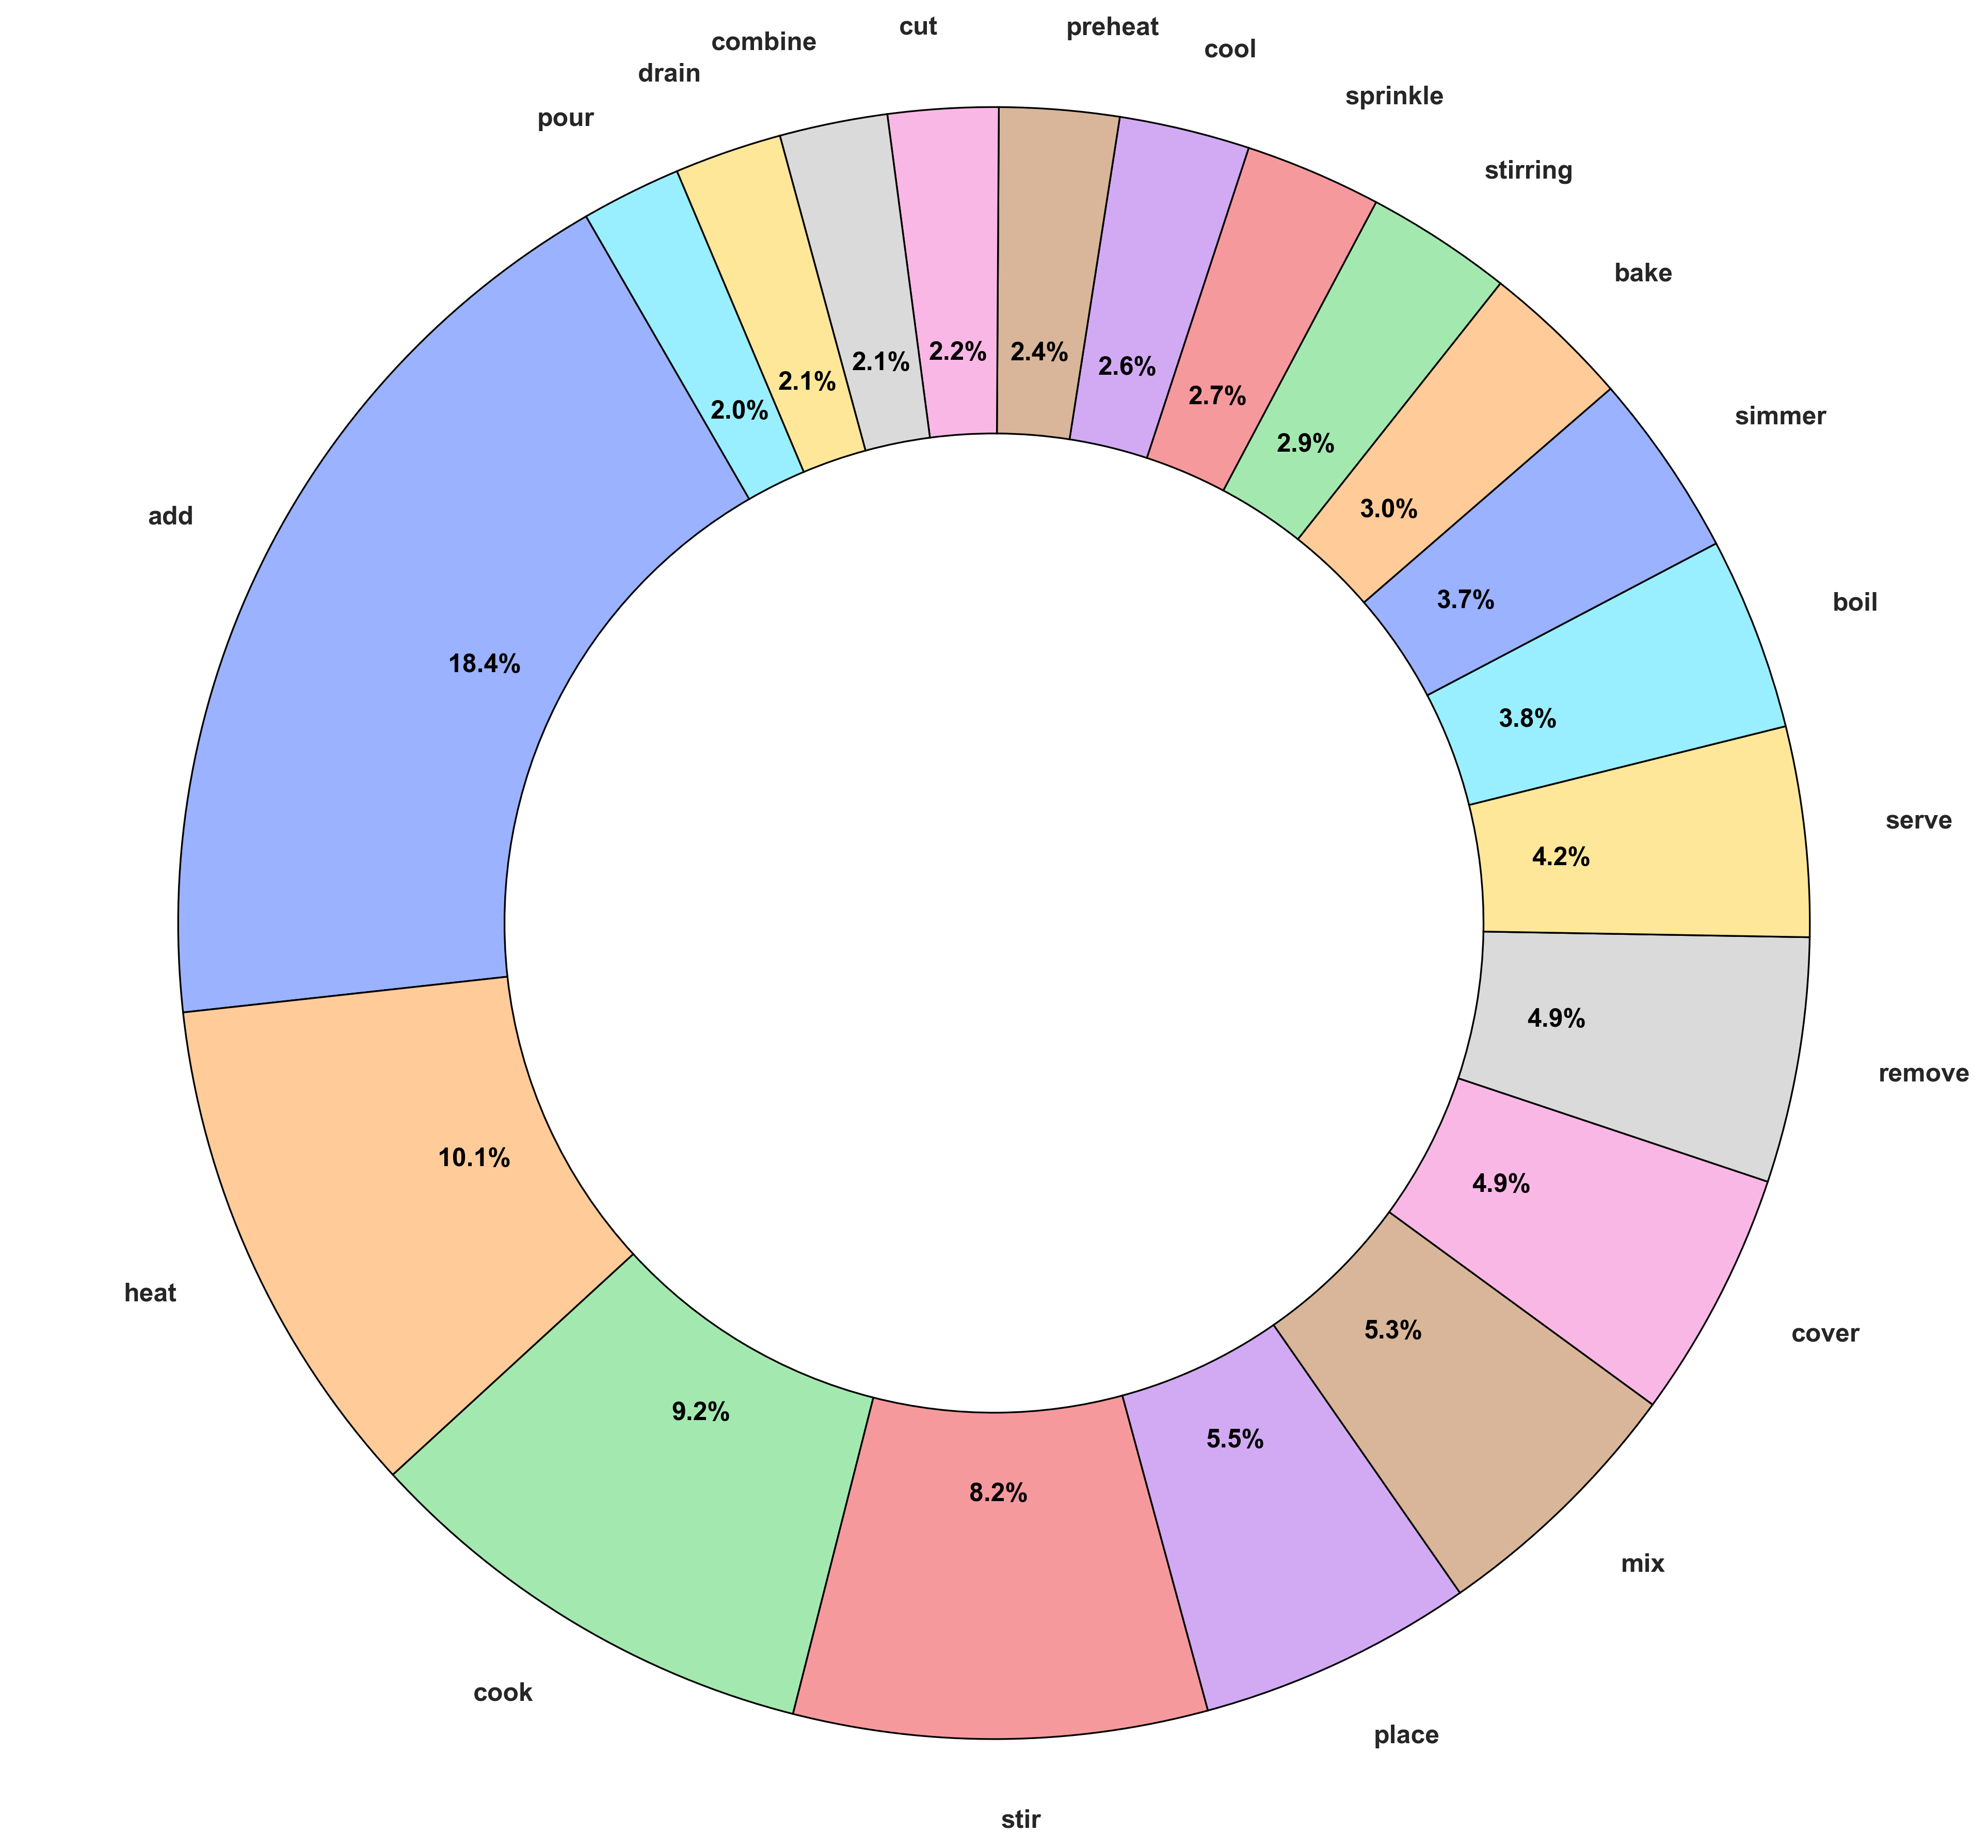

In [173]:
import pandas as pd
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 📂 Load precomputed file
# =========================
file_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Cooking_Action_Frequency.csv"
df = pd.read_csv(file_path)

# =========================
# 🧹 Clean
# =========================
df.columns = df.columns.str.strip()

# =========================
# 🔝 Top 20
# =========================
final_actions = df.head(20)

# =========================
# 🎨 Light color function
# =========================
def lighten_color(color, amount=0.6):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - np.array(c)) * (1 - amount))

# =========================
# 🎨 Colors (same style)
# =========================
base_colors = sns.color_palette("bright", len(final_actions))
light_colors = [lighten_color(c, 0.6) for c in base_colors]

# =========================
# 📊 DONUT PLOT
# =========================
plt.figure(figsize=(13, 12), dpi=300)

wedges, texts, autotexts = plt.pie(
    final_actions['frequency'],
    labels=final_actions['action'],
    autopct='%1.1f%%',
    startangle=120,
    colors=light_colors,
    textprops={'fontsize': 12, 'fontweight': 'bold', 'fontname': 'Arial'},
    wedgeprops={
        'linewidth': 0.8,
        'edgecolor': 'black',
        'width': 0.4
    },
    pctdistance=0.7,
    labeldistance=1.1
)

# =========================
# 🔤 Format %
# =========================
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(12)
    autotext.set_weight('bold')

plt.axis('equal')
plt.tight_layout()

# Save
plt.tight_layout()
plt.savefig("recipedb_instructions_doughnut_Light_color.png", dpi=300, bbox_inches="tight")

plt.show()

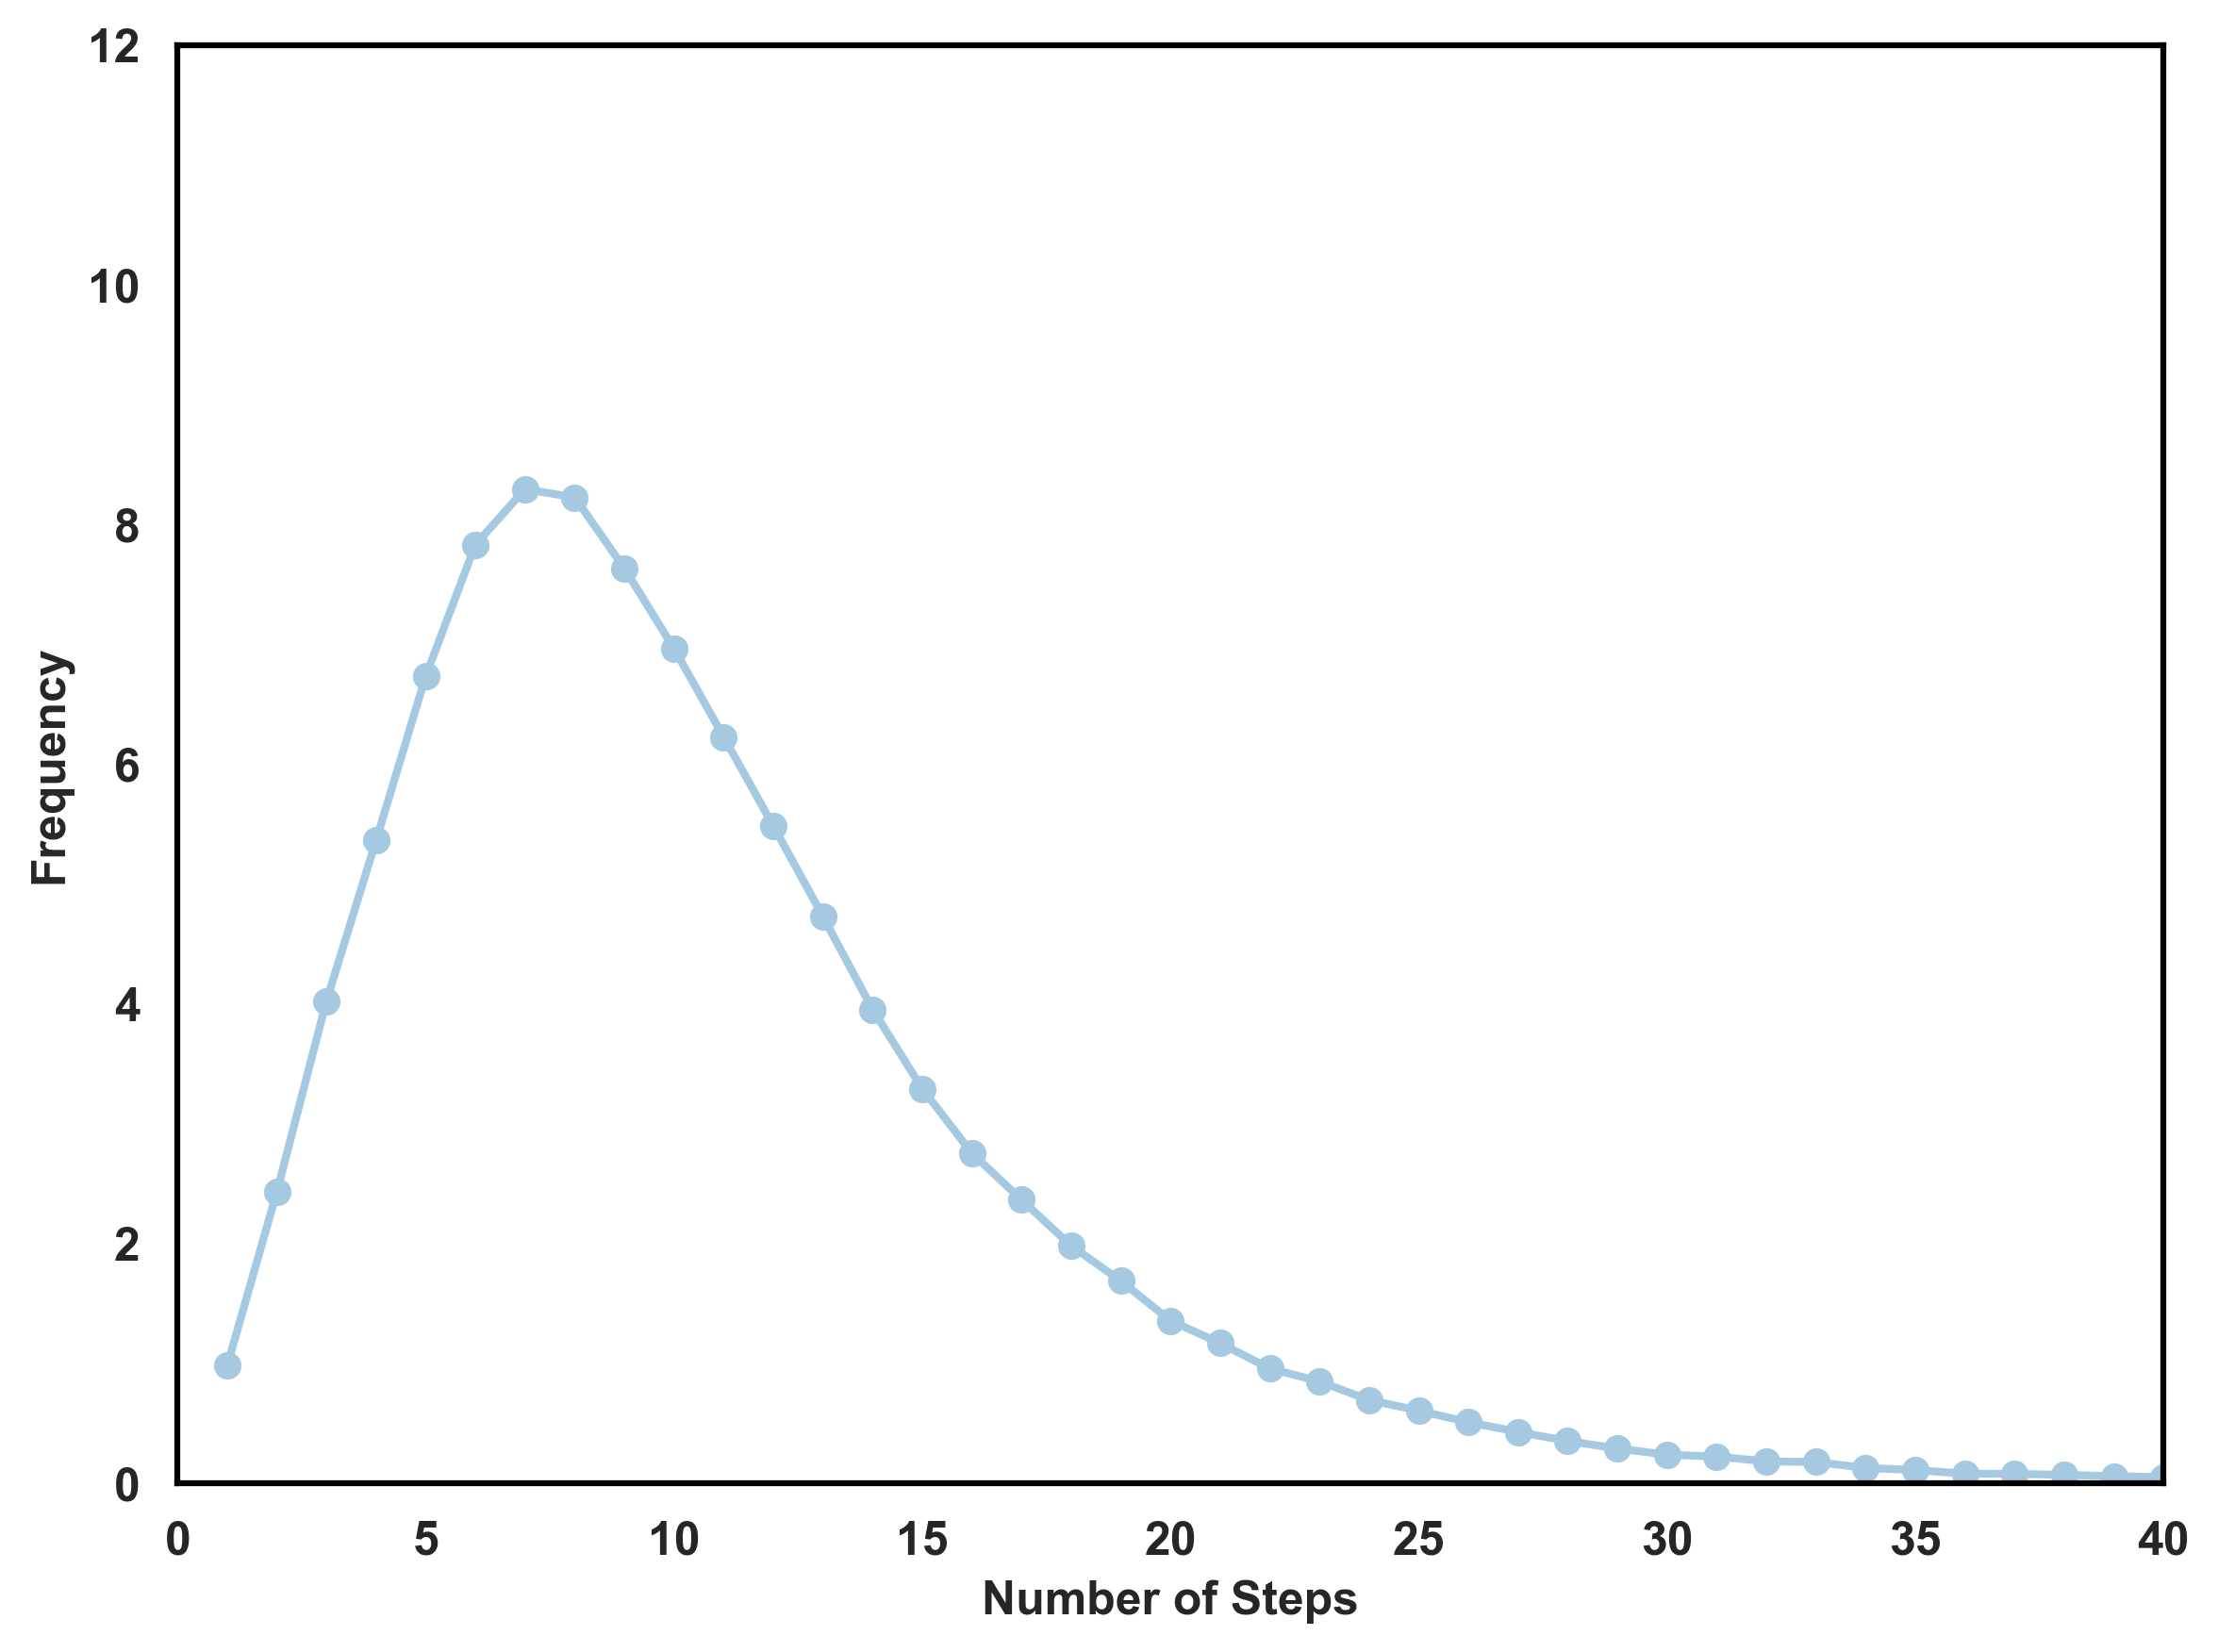

In [151]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import matplotlib.colors as mcolors

# =========================
# 🎨 Function to lighten color
# =========================
def lighten_color(color, amount=0.6):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - np.array(c)) * (1 - amount))

# =========================
# 📂 Load YOUR Data
# =========================
file_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Instruction_Phrases.csv"
output_dir = os.path.dirname(file_path)

df = pd.read_csv(file_path)

# =========================
# 🧹 Clean
# =========================
df.columns = df.columns.str.strip()
df['steps'] = df['steps'].astype(str)

# =========================
# 2️⃣ Compute Recipe Size
# =========================
df["recipe_size"] = df["steps"].apply(
    lambda x: len([s for s in x.split('.') if s.strip() != ""])
)

recipe_sizes = df["recipe_size"].values

# =========================
# 3️⃣ Count frequency
# =========================
size_counts = pd.Series(recipe_sizes).value_counts().sort_index()
sizes = size_counts.index
percentages = (size_counts.values / size_counts.values.sum()) * 100

# =========================
# 4️⃣ Average
# =========================
avg_size = round(np.mean(recipe_sizes))

# =========================
# 🎨 Light color (SAME)
# =========================
base_color = "#1f77b4"
light_color = lighten_color(base_color, 0.6)

# =========================
# 5️⃣ Plot
# =========================
plt.figure(figsize=(8, 6), dpi=300)
ax = plt.gca()

plt.plot(
    sizes,
    percentages,
    marker='o',
    linewidth=2,
    color=light_color
)

# Labels
plt.xlabel("Number of Steps", fontname='Arial', fontsize=12, fontweight='bold')
plt.ylabel("Frequency", fontname='Arial', fontsize=12, fontweight='bold')

# X-ticks
ax.set_xlim(0, 40)
ax.set_xticks(list(range(0, 41, 5)))

# Y-ticks
max_y_limit = 12
ax.set_yticks(list(range(0, max_y_limit + 2, 2)))
ax.set_ylim(0, max_y_limit)

# Tick font
plt.xticks(fontname='Arial', fontsize=12, fontweight='bold')
plt.yticks(fontname='Arial', fontsize=12, fontweight='bold')

# Border styling
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1.5)

# Remove grid
plt.grid(False)

# =========================
# 💾 Save (same folder)
# =========================
plt.tight_layout()

save_path = os.path.join(output_dir, "instruction_recipe_size_distribution_Light_color.png")

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


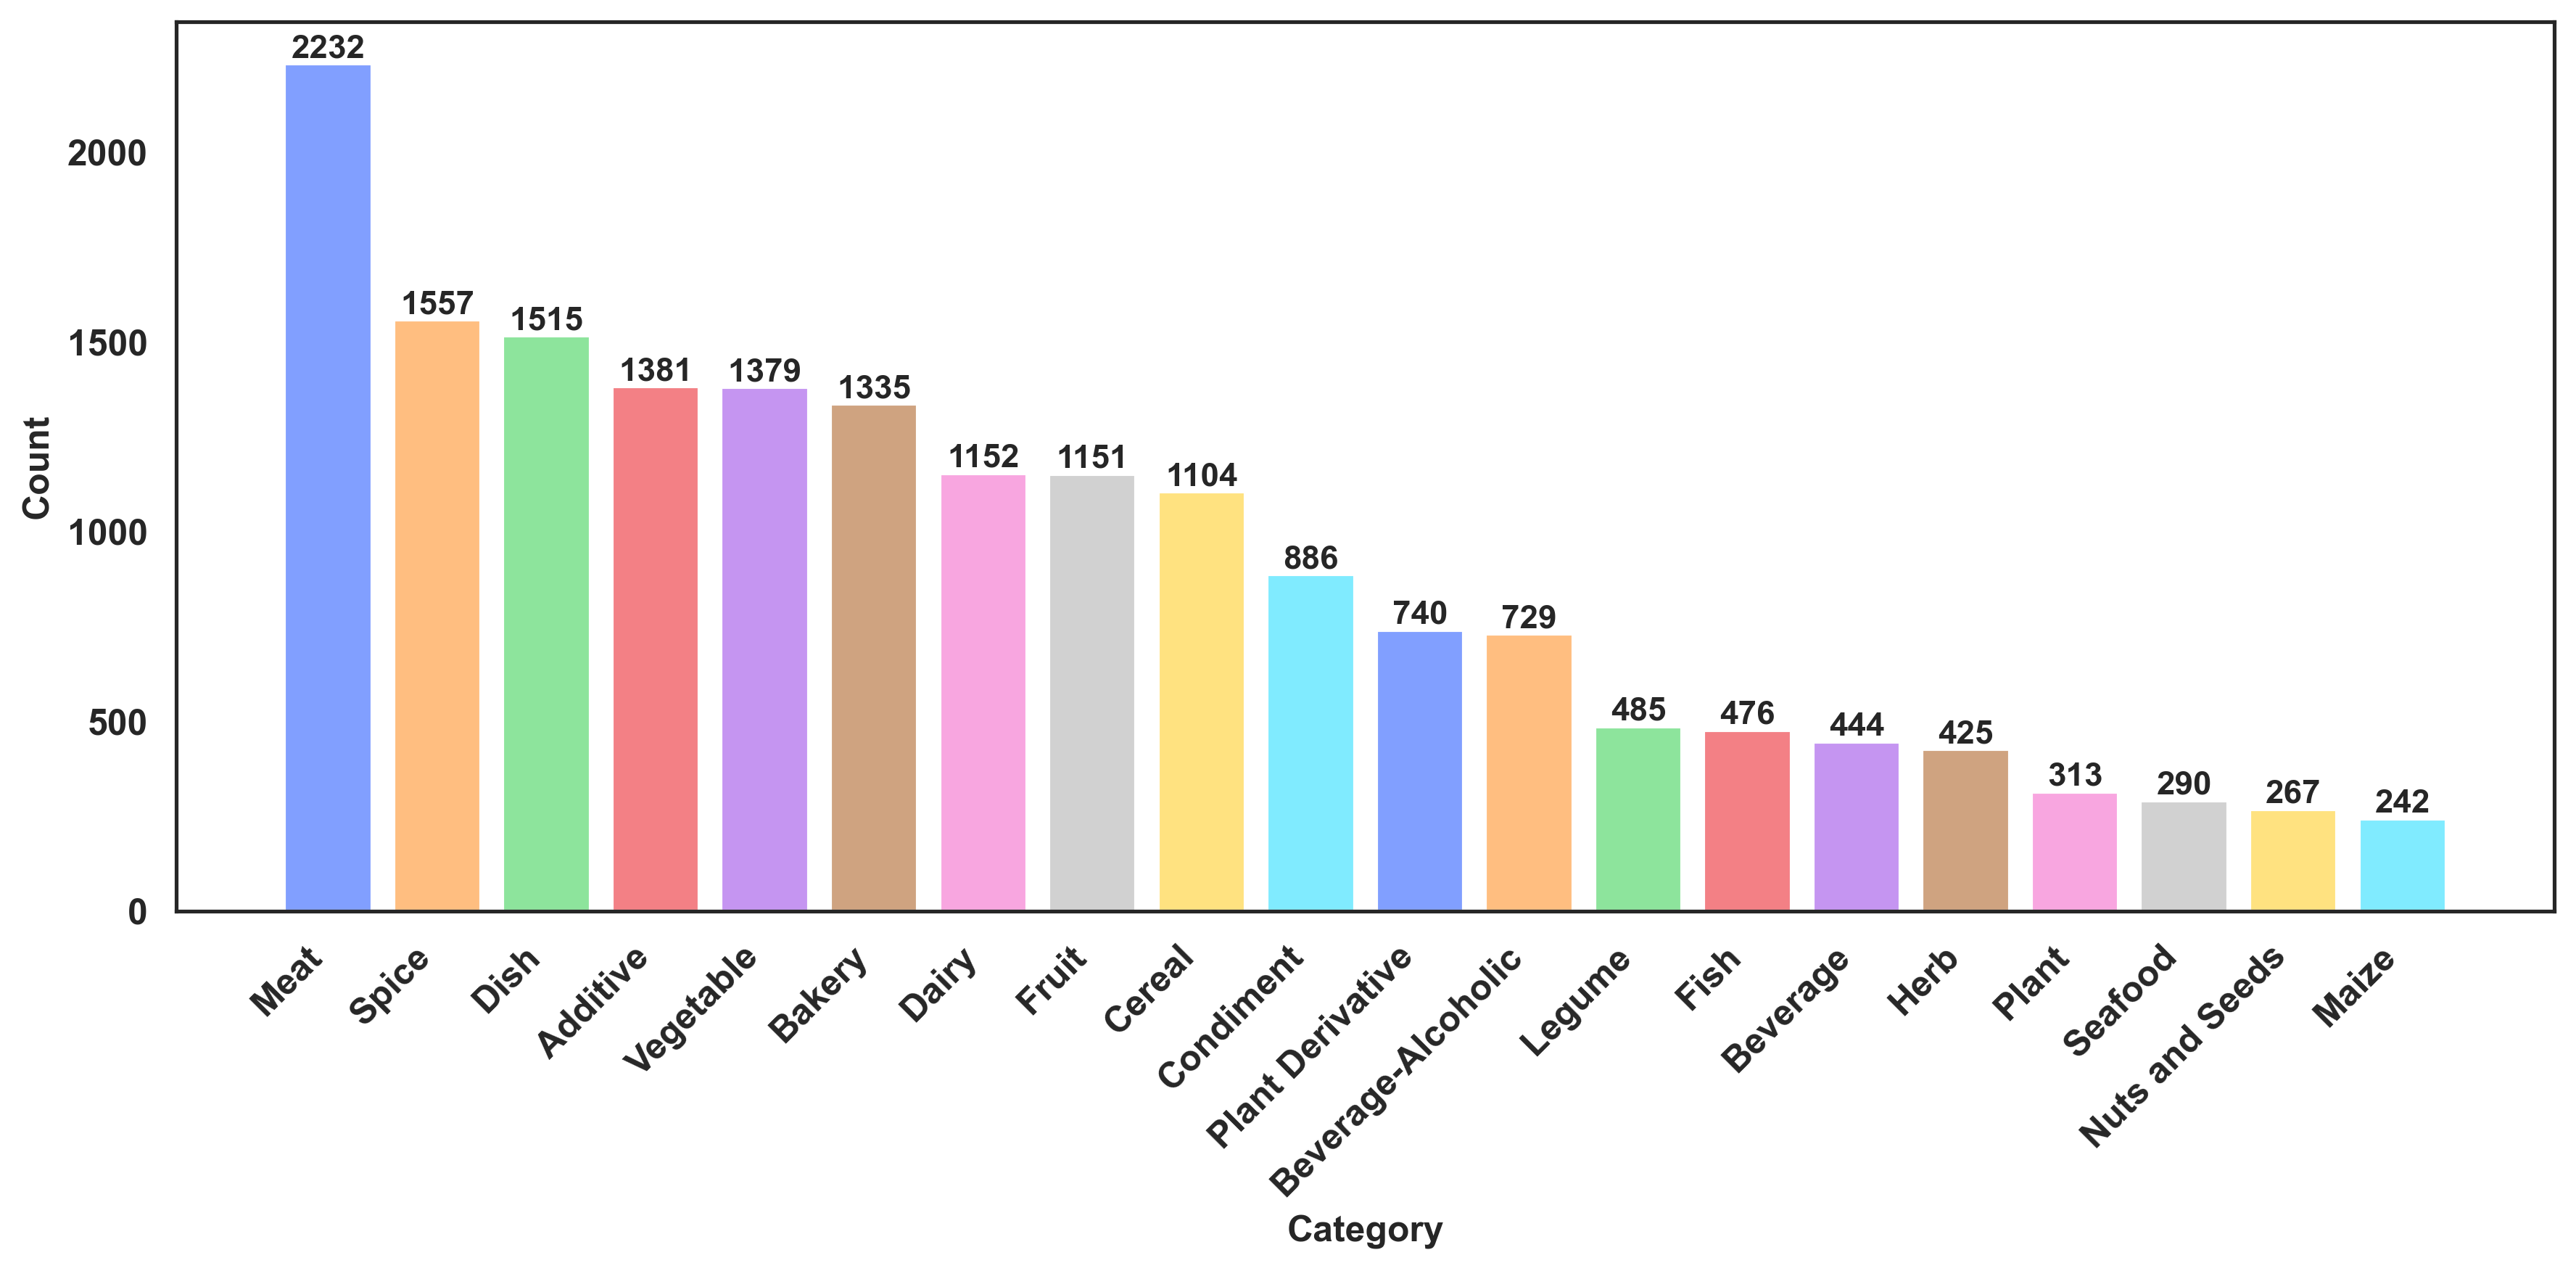

✅ Saved: Top20_Ingredient_Categories_BarPlot_Light.png


In [153]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors

# =========================
# 🎨 Function to lighten color
# =========================
def lighten_color(color, amount=0.5):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - np.array(c)) * (1 - amount))

# =========================
# 📂 Load Data
# =========================
file_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Ingredient_Category.csv"
df = pd.read_csv(file_path)

# =========================
# 🧹 Clean
# =========================
df.columns = df.columns.str.strip()
df['Dietrx_Category'] = df['Dietrx_Category'].astype(str).str.strip()

# =========================
# 🔝 Top 20 categories
# =========================
top_categories = df['Dietrx_Category'].value_counts().head(20)

# =========================
# 🎨 Light colors
# =========================
base_colors = sns.color_palette("bright", n_colors=len(top_categories))
light_colors = [lighten_color(c, 0.5) for c in base_colors]

# =========================
# 📊 Plot
# =========================
plt.figure(figsize=(12, 6), dpi=300)

bars = plt.bar(
    top_categories.index,
    top_categories.values,
    color=light_colors   # ✅ no border now
)

# =========================
# 🔤 Formatting
# =========================
plt.xticks(fontsize=12, fontweight='bold', rotation=45, ha='right', fontname='Arial')
plt.yticks(fontsize=12, fontweight='bold', fontname='Arial')

plt.xlabel("Category", fontsize=12, fontweight='bold', fontname='Arial')
plt.ylabel("Count", fontsize=12, fontweight='bold', fontname='Arial')

# =========================
# 🔢 Value labels
# =========================
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.5,
        int(yval),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
        fontname='Arial'
    )

# Clean look
plt.grid(False)

# =========================
# 💾 Save
# =========================
plt.tight_layout()
plt.savefig("Top20_Ingredient_Categories_BarPlot_Light.png", dpi=300, bbox_inches="tight")

plt.show()

print("✅ Saved: Top20_Ingredient_Categories_BarPlot_Light.png")

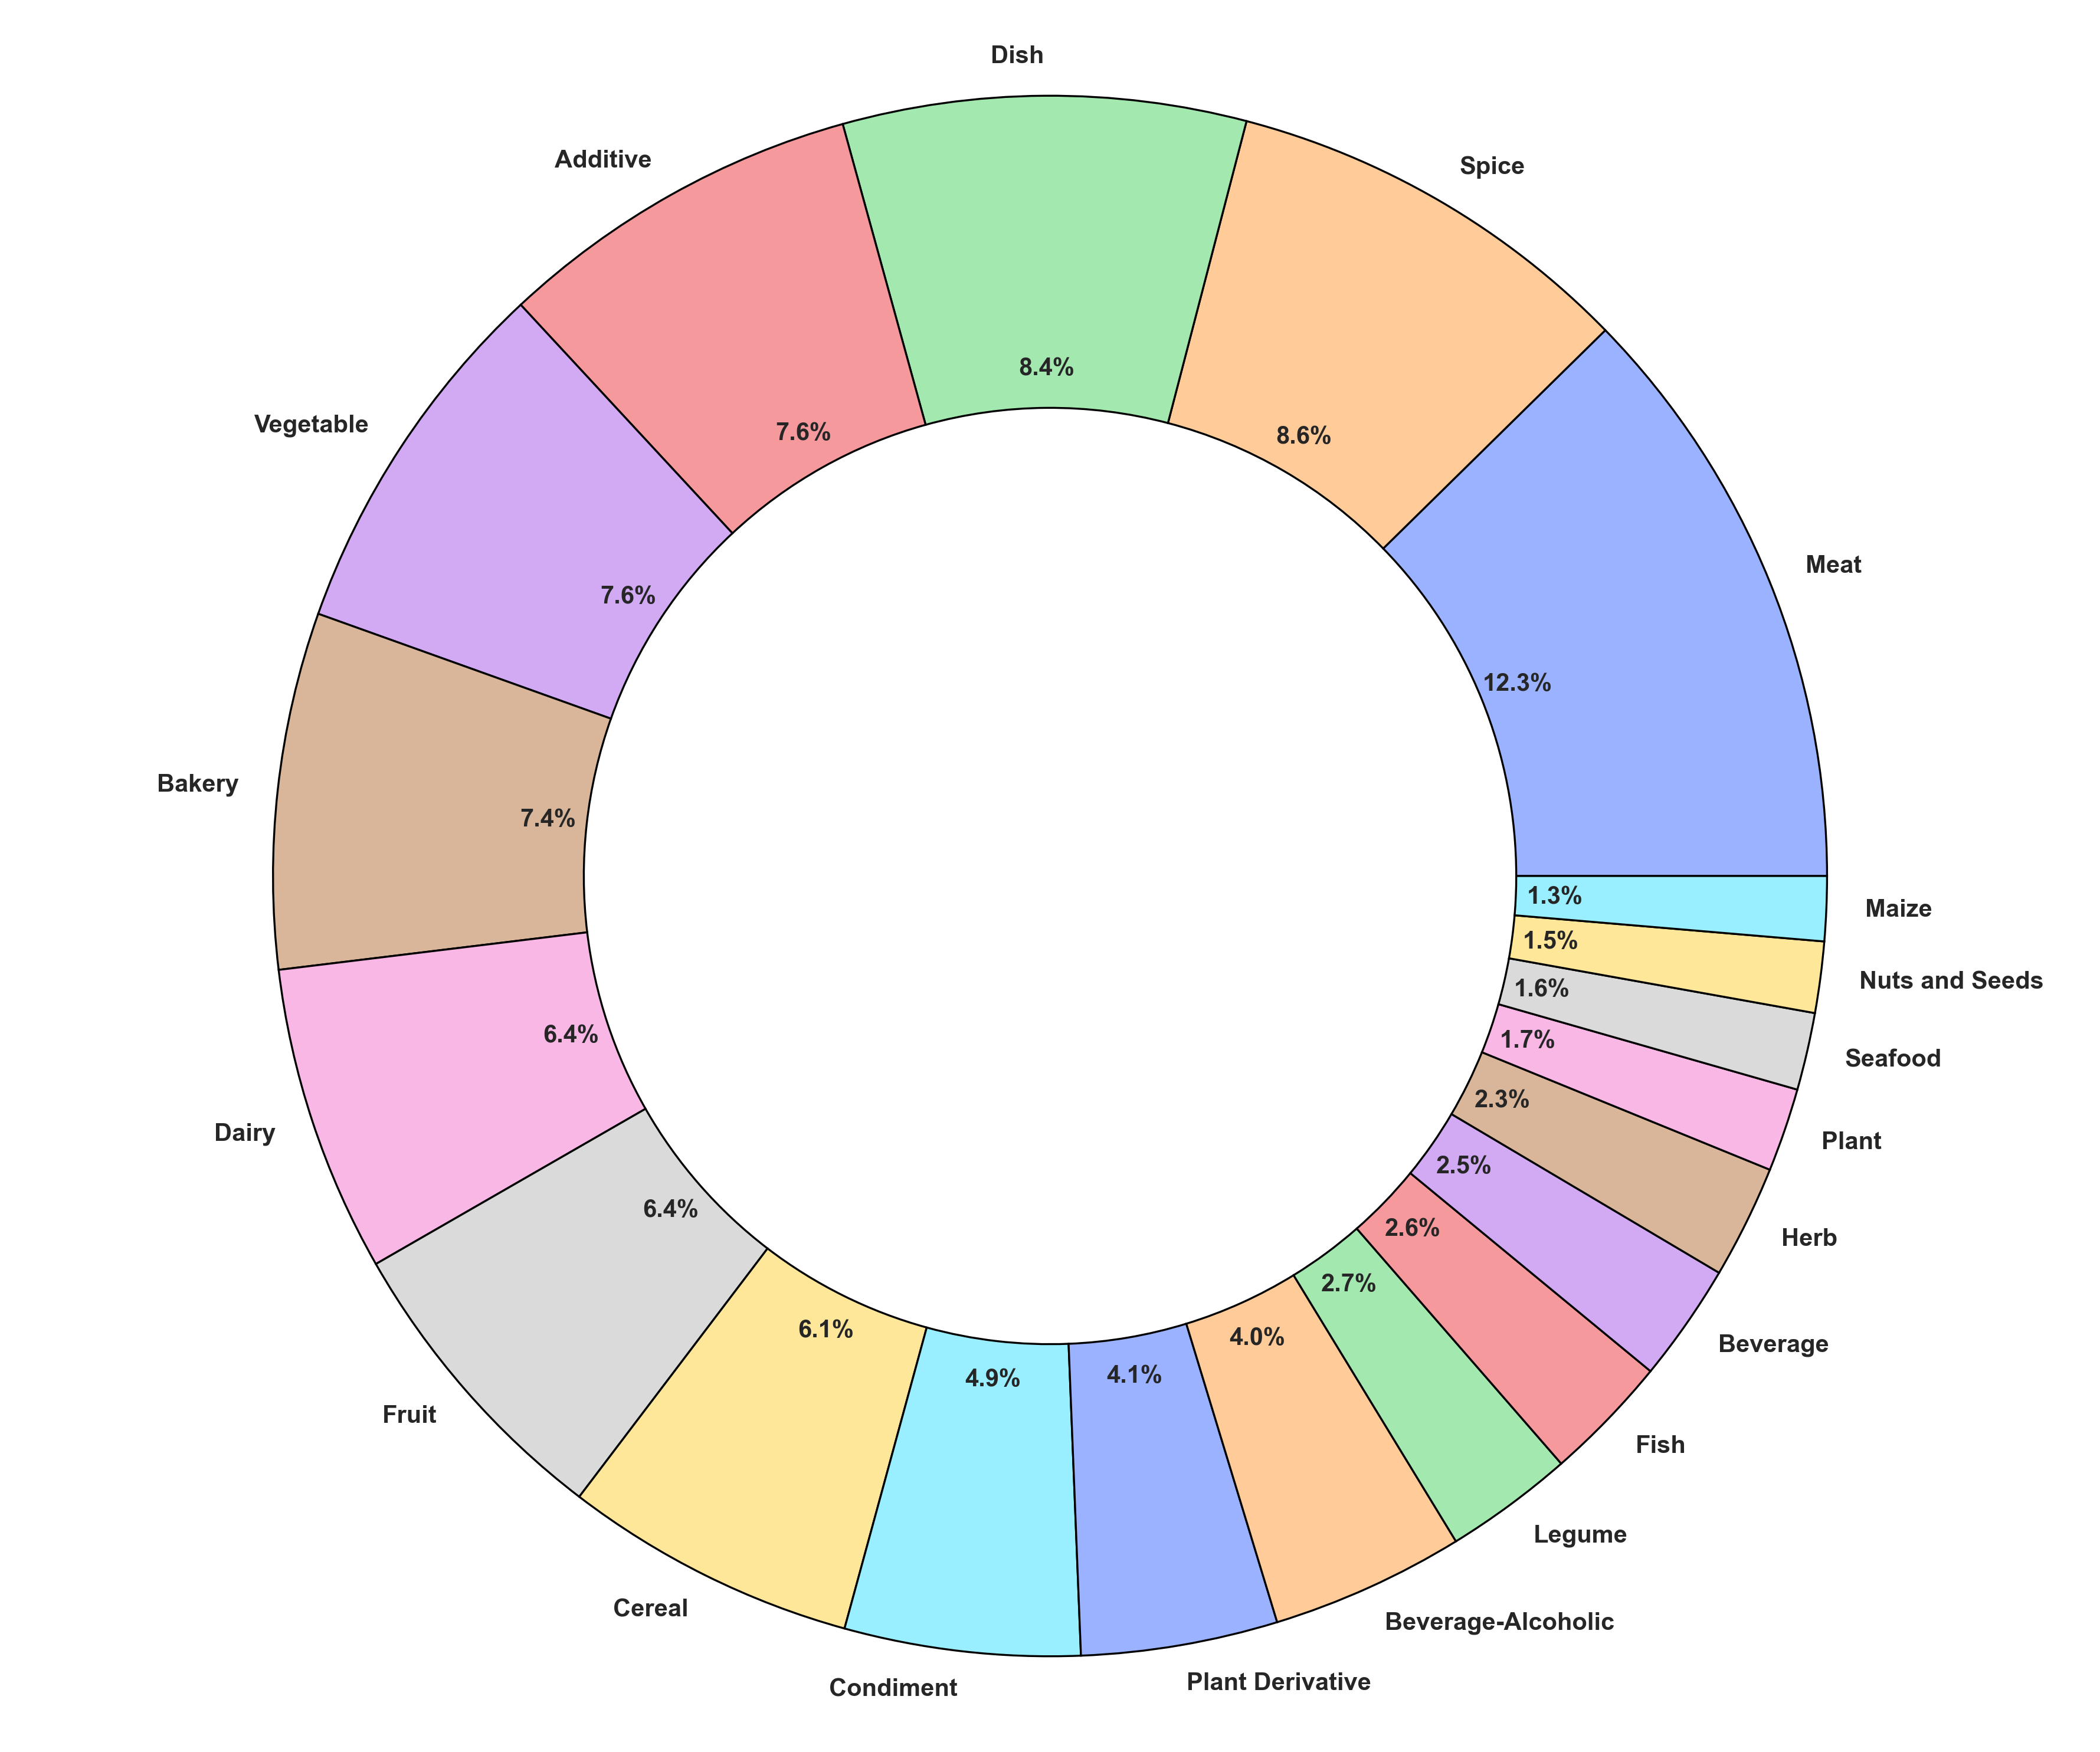

✅ Saved: Clean donut chart with reduced overlap


In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import matplotlib.colors as mcolors

# =========================
# 🎨 Function to lighten color
# =========================
def lighten_color(color, amount=0.6):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - np.array(c)) * (1 - amount))

# -------------------
# Load Data
# -------------------
file_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Ingredient_Category.csv"
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()
df['Dietrx_Category'] = df['Dietrx_Category'].astype(str).str.strip()

# Top 20 categories
top_categories = df['Dietrx_Category'].value_counts().head(20)

# =========================
# 🎨 Light palette
# =========================
base_colors = sns.color_palette("bright", len(top_categories))
light_colors = [lighten_color(c, 0.6) for c in base_colors]

# =========================
# 🎨 Font (slightly reduced to avoid overlap)
# =========================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 10   # 🔥 reduced from 12
plt.rcParams['font.weight'] = 'bold'

# -------------------
# Plot Donut Chart
# -------------------
plt.figure(figsize=(12, 10), dpi=300)  # 🔥 bigger figure = less overlap

plt.pie(
    top_categories.values,
    labels=top_categories.index,
    colors=light_colors,
    autopct='%1.1f%%',

    # 🔥 FIXED spacing (small but effective)
    pctdistance=0.65,   # moved inward slightly
    labeldistance=1.05, # closer to donut (IMPORTANT FIX)

    textprops={
        'fontsize': 10,
        'fontweight': 'bold',
        'fontname': 'Arial'
    },

    wedgeprops={
        'edgecolor': 'black',
        'linewidth': 0.8,
        'width': 0.4
    }
)

plt.axis('equal')
plt.grid(False)

# -------------------
# Save
# -------------------
output_dir = os.getcwd()

plt.tight_layout()

plt.savefig(
    os.path.join(output_dir, "Top20_Ingredient_Category_DonutChart_Light_fixed.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved: Clean donut chart with reduced overlap")

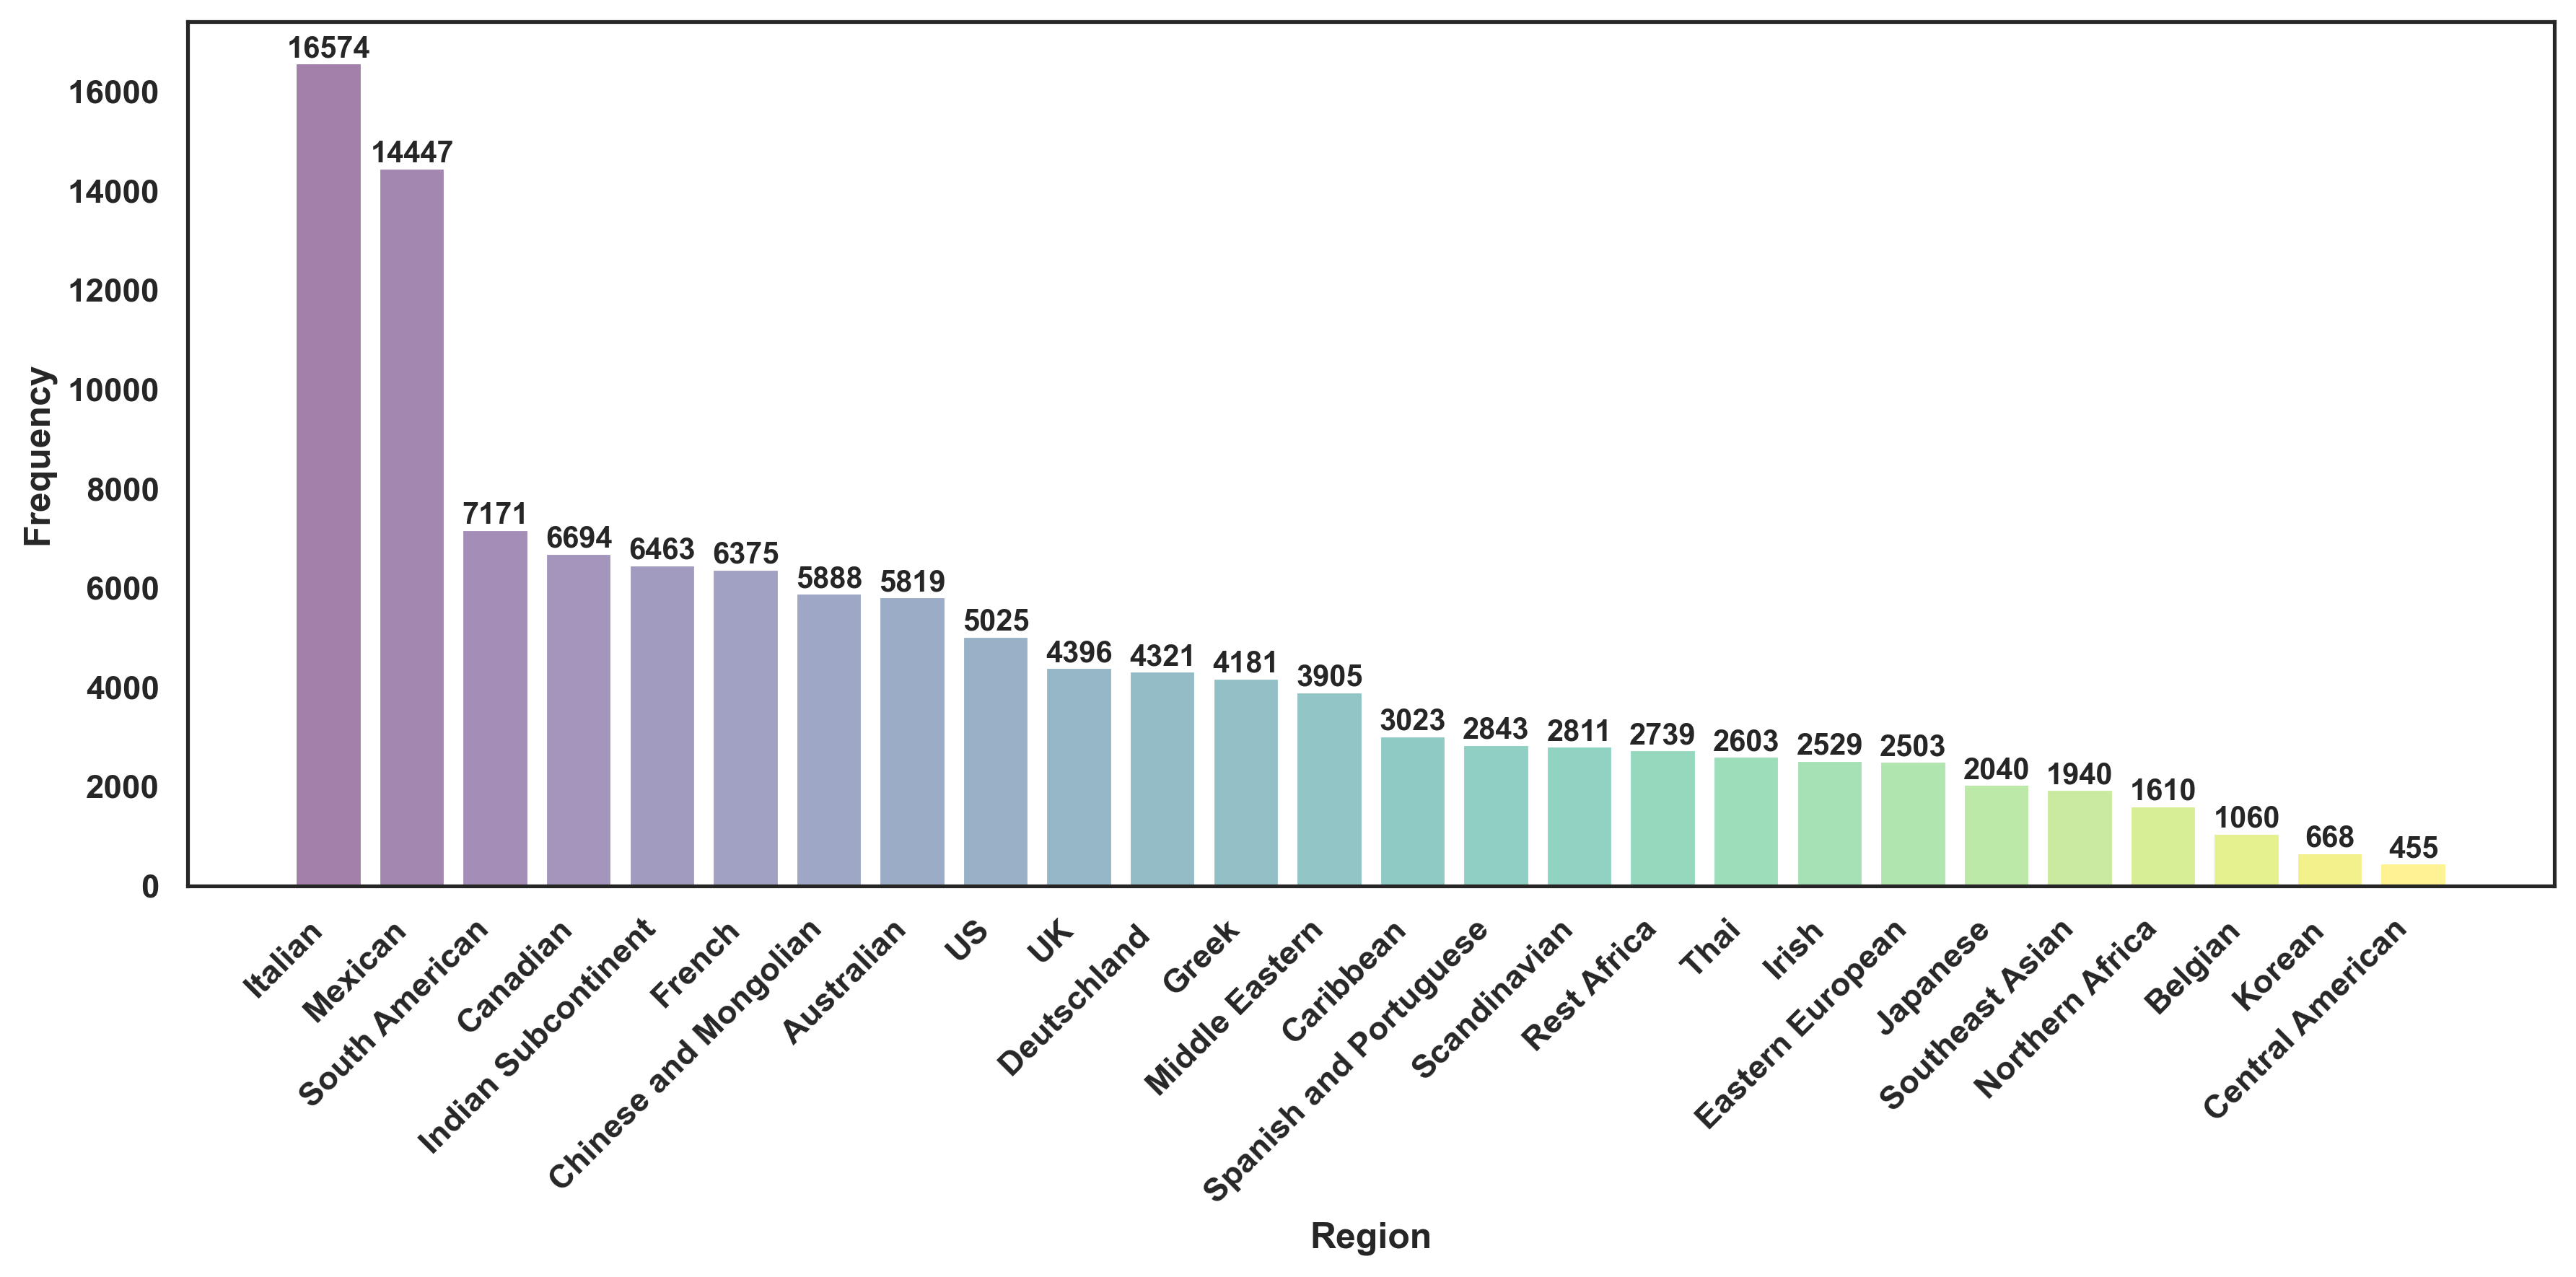

✅ Saved: C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git\Cuisine_regions_barplot_Light_color.png


In [157]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import os

# =========================
# 🎨 Function to lighten color
# =========================
def lighten_color(color, amount=0.5):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - np.array(c)) * (1 - amount))

# =========================
# 📂 Load YOUR FILE
# =========================
file_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/region_recipe_counts_descending.csv"
output_dir = os.path.dirname(file_path)

df = pd.read_csv(file_path)

# =========================
# 🧹 Clean
# =========================
df.columns = df.columns.str.strip()

# =========================
# 🔝 Top 26 Regions
# =========================
top_regions = df.head(26)

# =========================
# 📊 Plot
# =========================
plt.figure(figsize=(12, 6), dpi=300)

# 🎨 Light Viridis colors
base_colors = plt.cm.viridis(np.linspace(0, 1, len(top_regions)))
colors = [lighten_color(c, 0.5) for c in base_colors]

bars = plt.bar(
    top_regions['Region'],
    top_regions['Recipe_Count'],
    color=colors
)

# =========================
# 🔢 Labels on bars
# =========================
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

# =========================
# 🏷 Labels
# =========================
plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

plt.xlabel("Region", fontweight='bold', fontsize=12)
plt.ylabel("Frequency", fontweight='bold', fontsize=12)

plt.grid(False)

# =========================
# 💾 Save (same folder)
# =========================
plt.tight_layout()

save_path = os.path.join(output_dir, "Cuisine_regions_barplot_Light_color.png")

plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("✅ Saved:", save_path)

C:\Users\madhu\AppData\Local\Temp\ipykernel_14128\1391319723.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\madhu\AppData\Local\Temp\ipykernel_14128\1391319723.py:39: UserWarning: The palette list has more values (20) than needed (19), which may not be intended.
  sns.barplot(


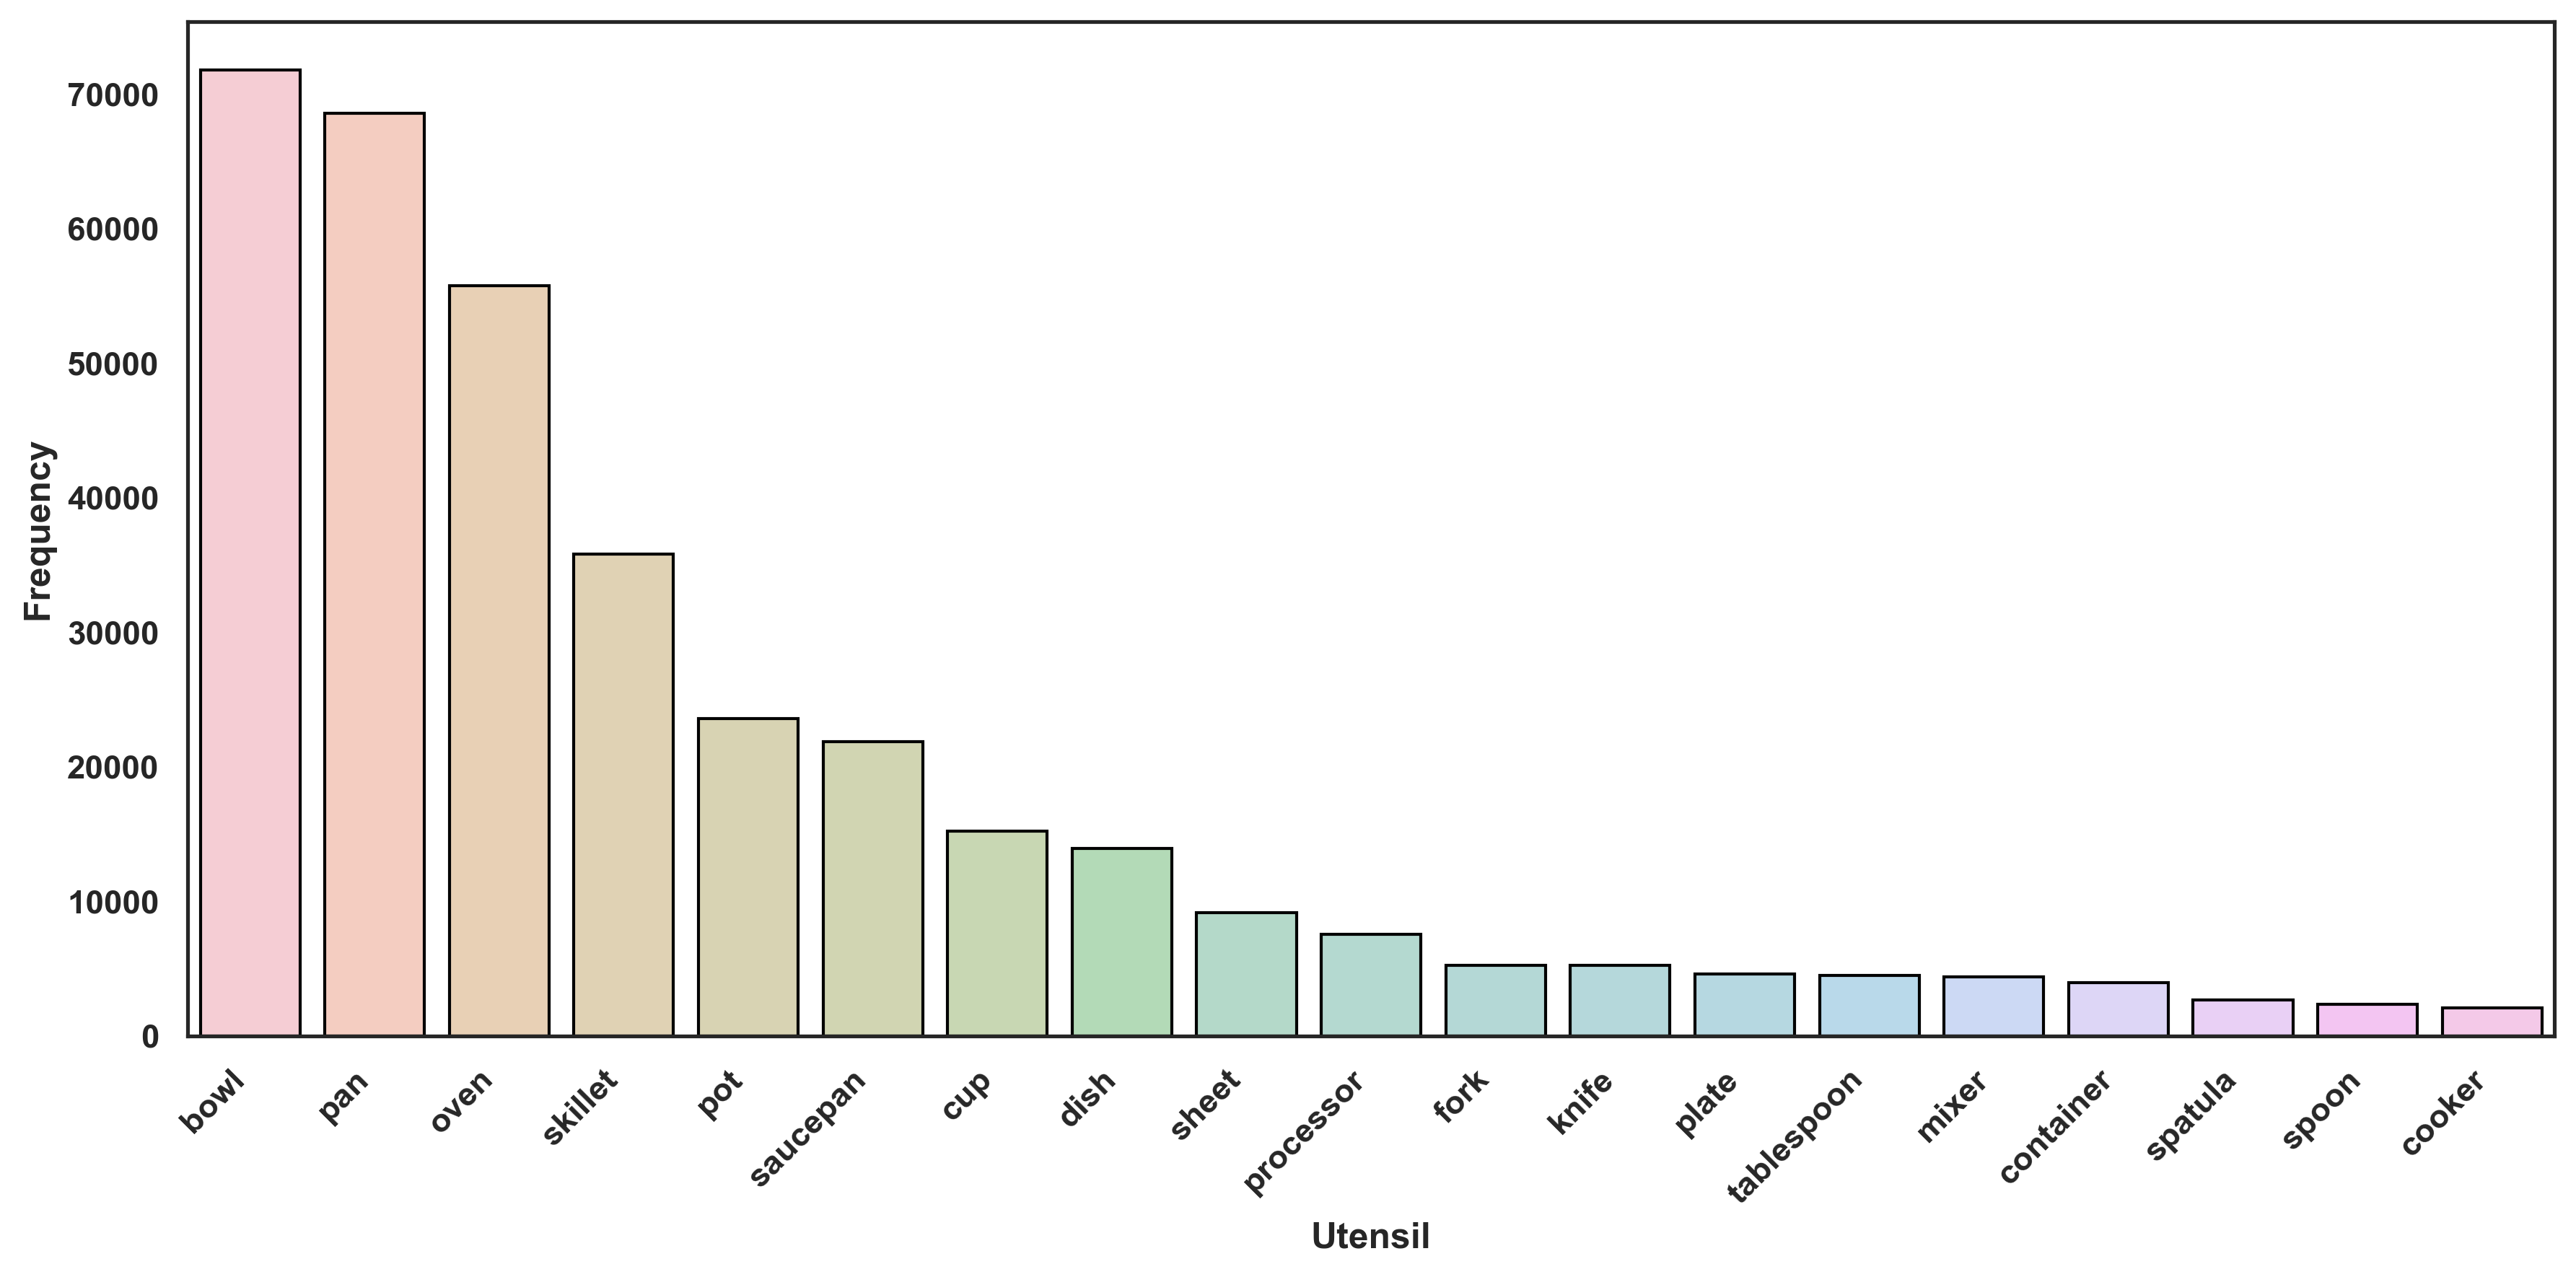

✅ Saved: C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git\Top_20_Most_Common_Utensils_Light_color.png


In [159]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors
import os

# =========================
# 🎨 Function to lighten color
# =========================
def lighten_color(color, amount=0.6):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - np.array(c)) * (1 - amount))

# =========================
# 📂 Load file
# =========================
file_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Utensil_Frequency.csv"
output_dir = os.path.dirname(file_path)

df = pd.read_csv(file_path)

# =========================
# 🔝 Top 20 utensils
# =========================
top_utensils = df.head(20)

# =========================
# 🎨 Light HUSL palette (same style)
# =========================
base_palette = sns.color_palette("husl", n_colors=len(top_utensils))
light_palette = [lighten_color(c, 0.6) for c in base_palette]

# =========================
# 📊 Plot
# =========================
plt.figure(figsize=(12,6), dpi=300)

sns.barplot(
    x=top_utensils['Utensil'],
    y=top_utensils['Frequency'],
    palette=light_palette,
    edgecolor='black'
)

# =========================
# 🏷 Labels
# =========================
plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')
plt.yticks(fontsize=11, fontweight='bold')

plt.xlabel("Utensil", fontweight='bold')
plt.ylabel("Frequency", fontweight='bold')

plt.grid(False)

# =========================
# 💾 Save
# =========================
plt.tight_layout()

save_path = os.path.join(output_dir, "Top_20_Most_Common_Utensils_Light_color.png")

plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("✅ Saved:", save_path)

Columns found: ['utensils']


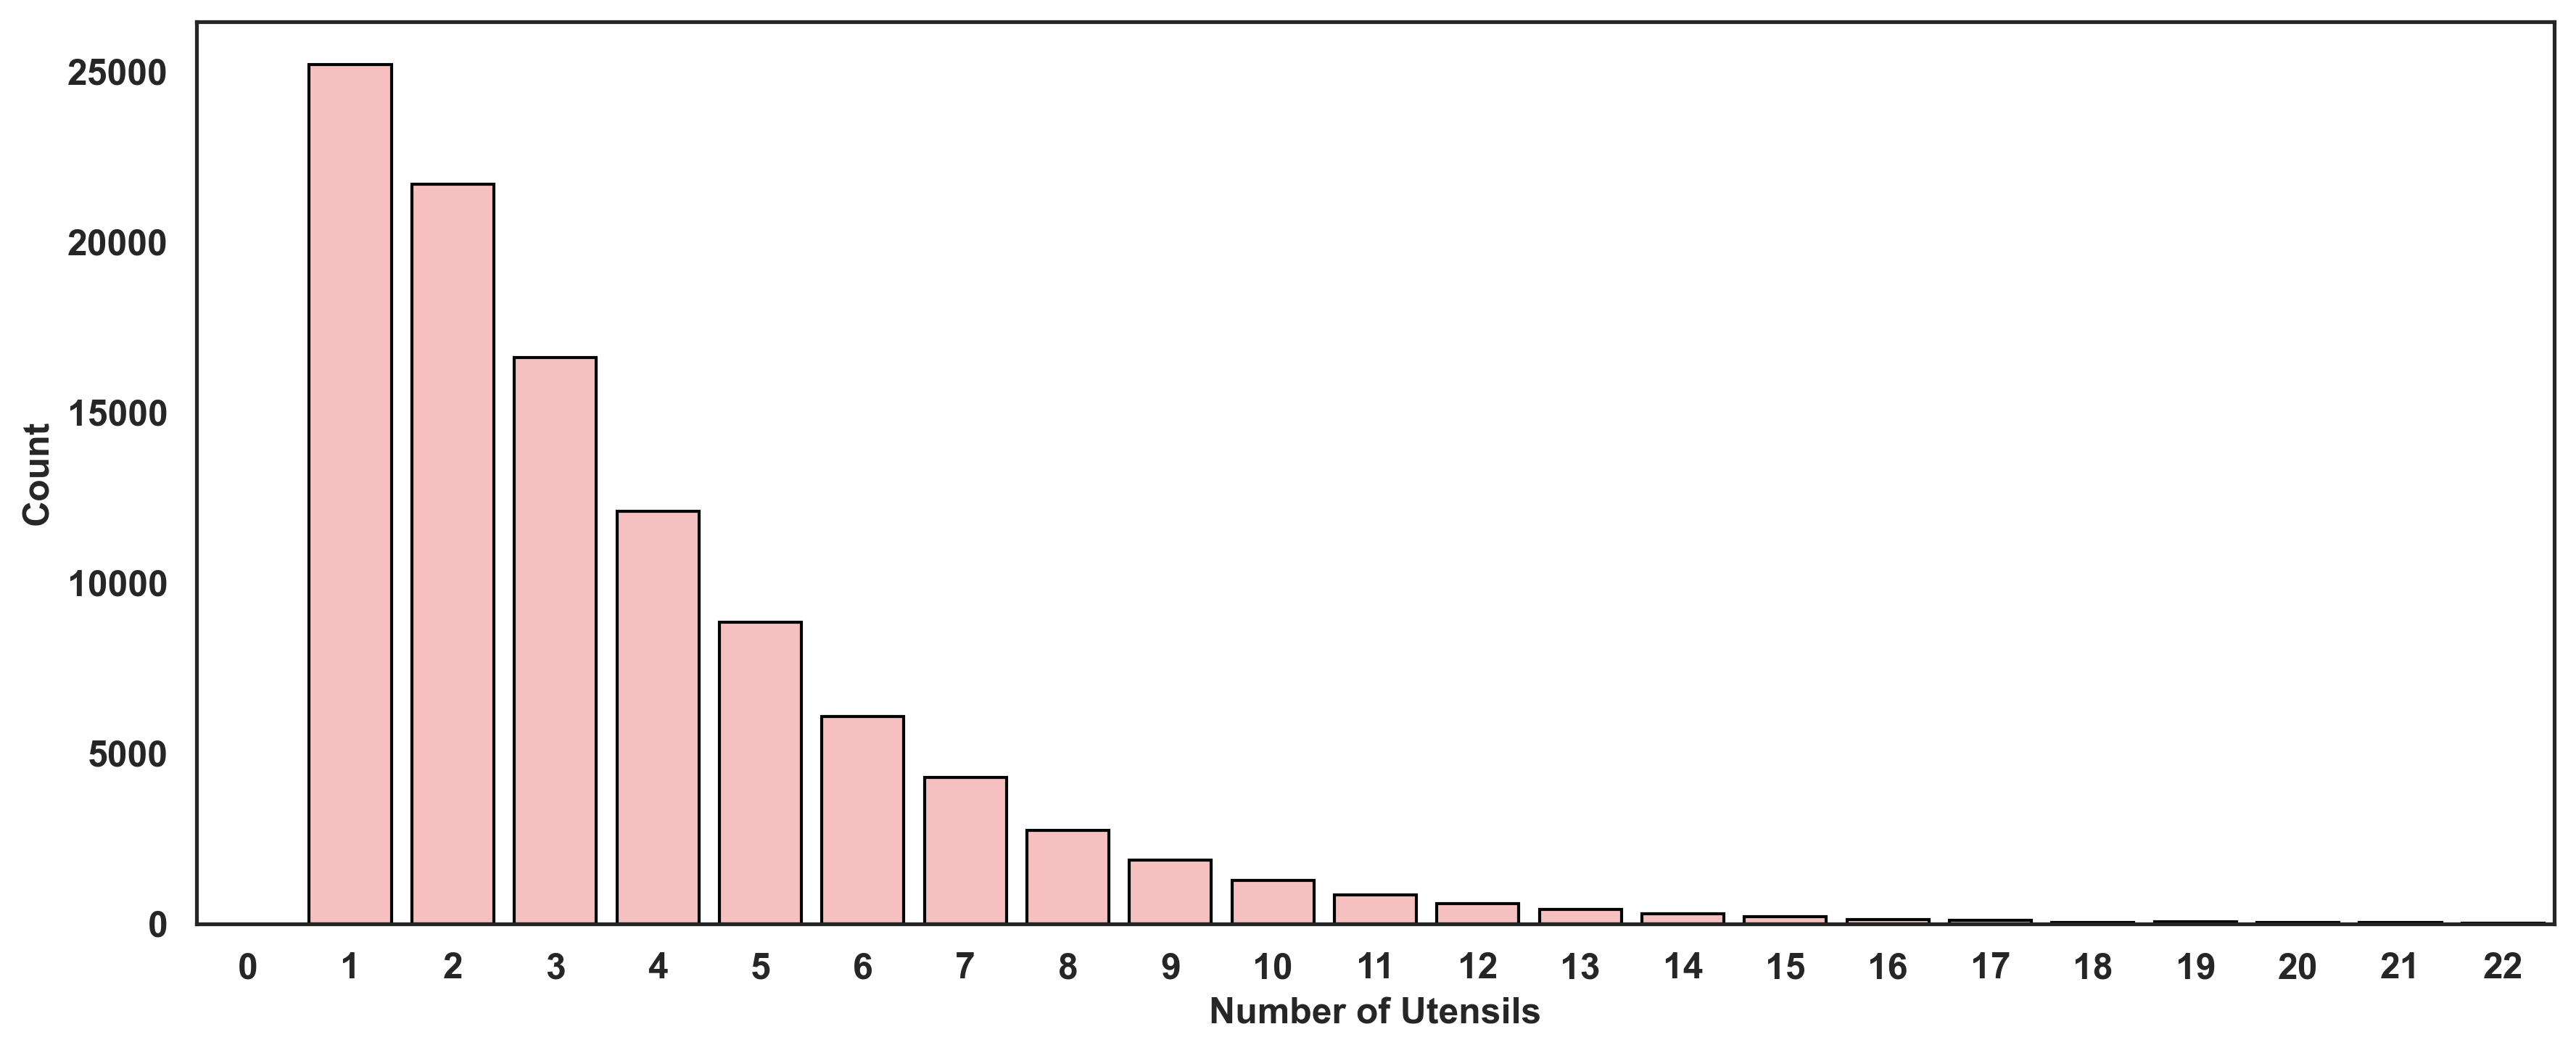

✅ Plot saved successfully


In [161]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

# =========================
# 🎨 Font settings (GLOBAL)
# =========================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'

# =========================
# 🎨 Color function
# =========================
def lighten_color(color, amount=0.6):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - np.array(c)) * (1 - amount))

# =========================
# 📂 Load data
# =========================
file_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Utensil.csv"
df = pd.read_csv(file_path)

# =========================
# 🧹 Clean column names
# =========================
df.columns = (
    df.columns.astype(str)
    .str.replace("\r", "", regex=True)
    .str.replace("\n", "", regex=True)
    .str.strip()
    .str.lower()
)

print("Columns found:", df.columns.tolist())

# auto column
col = df.columns[0]

# =========================
# 🧹 Split utensils
# =========================
df['utensils_list'] = df[col].astype(str).str.lower().str.split(r'\|\|')

df['utensils_list'] = df['utensils_list'].apply(
    lambda x: [i.strip() for i in x if i and i.strip() != '']
)

# =========================
# 📊 Count utensils
# =========================
df['num_utensils'] = df['utensils_list'].apply(len)

# =========================
# 🎨 Color
# =========================
base_color = '#FF4C4C'
light_color = lighten_color(base_color, 0.6)

# =========================
# 📊 Plot
# =========================
plt.figure(figsize=(12, 5), dpi=300)

sns.countplot(
    x=df['num_utensils'],
    order=range(0, 23),
    color=light_color,
    edgecolor='black'
)

# =========================
# 📏 Axis (0–22 fixed)
# =========================
plt.xlim(-0.5, 22.5)
plt.xticks(range(0, 23, 1), fontsize=12, fontweight='bold')

# =========================
# 🏷 Labels (Arial + bold 12)
# =========================
plt.xlabel("Number of Utensils", fontsize=12, fontweight='bold', fontname='Arial')
plt.ylabel("Count", fontsize=12, fontweight='bold', fontname='Arial')

# =========================
# 🧾 Tick styling
# =========================
plt.yticks(fontsize=12, fontweight='bold', fontname='Arial')

plt.tight_layout()

# =========================
# 💾 Save
# =========================
plt.savefig(
    "Number_of_Utensils_per_Recipe_Arial_Bold.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Plot saved successfully")

Columns found: ['region', 'utensils']


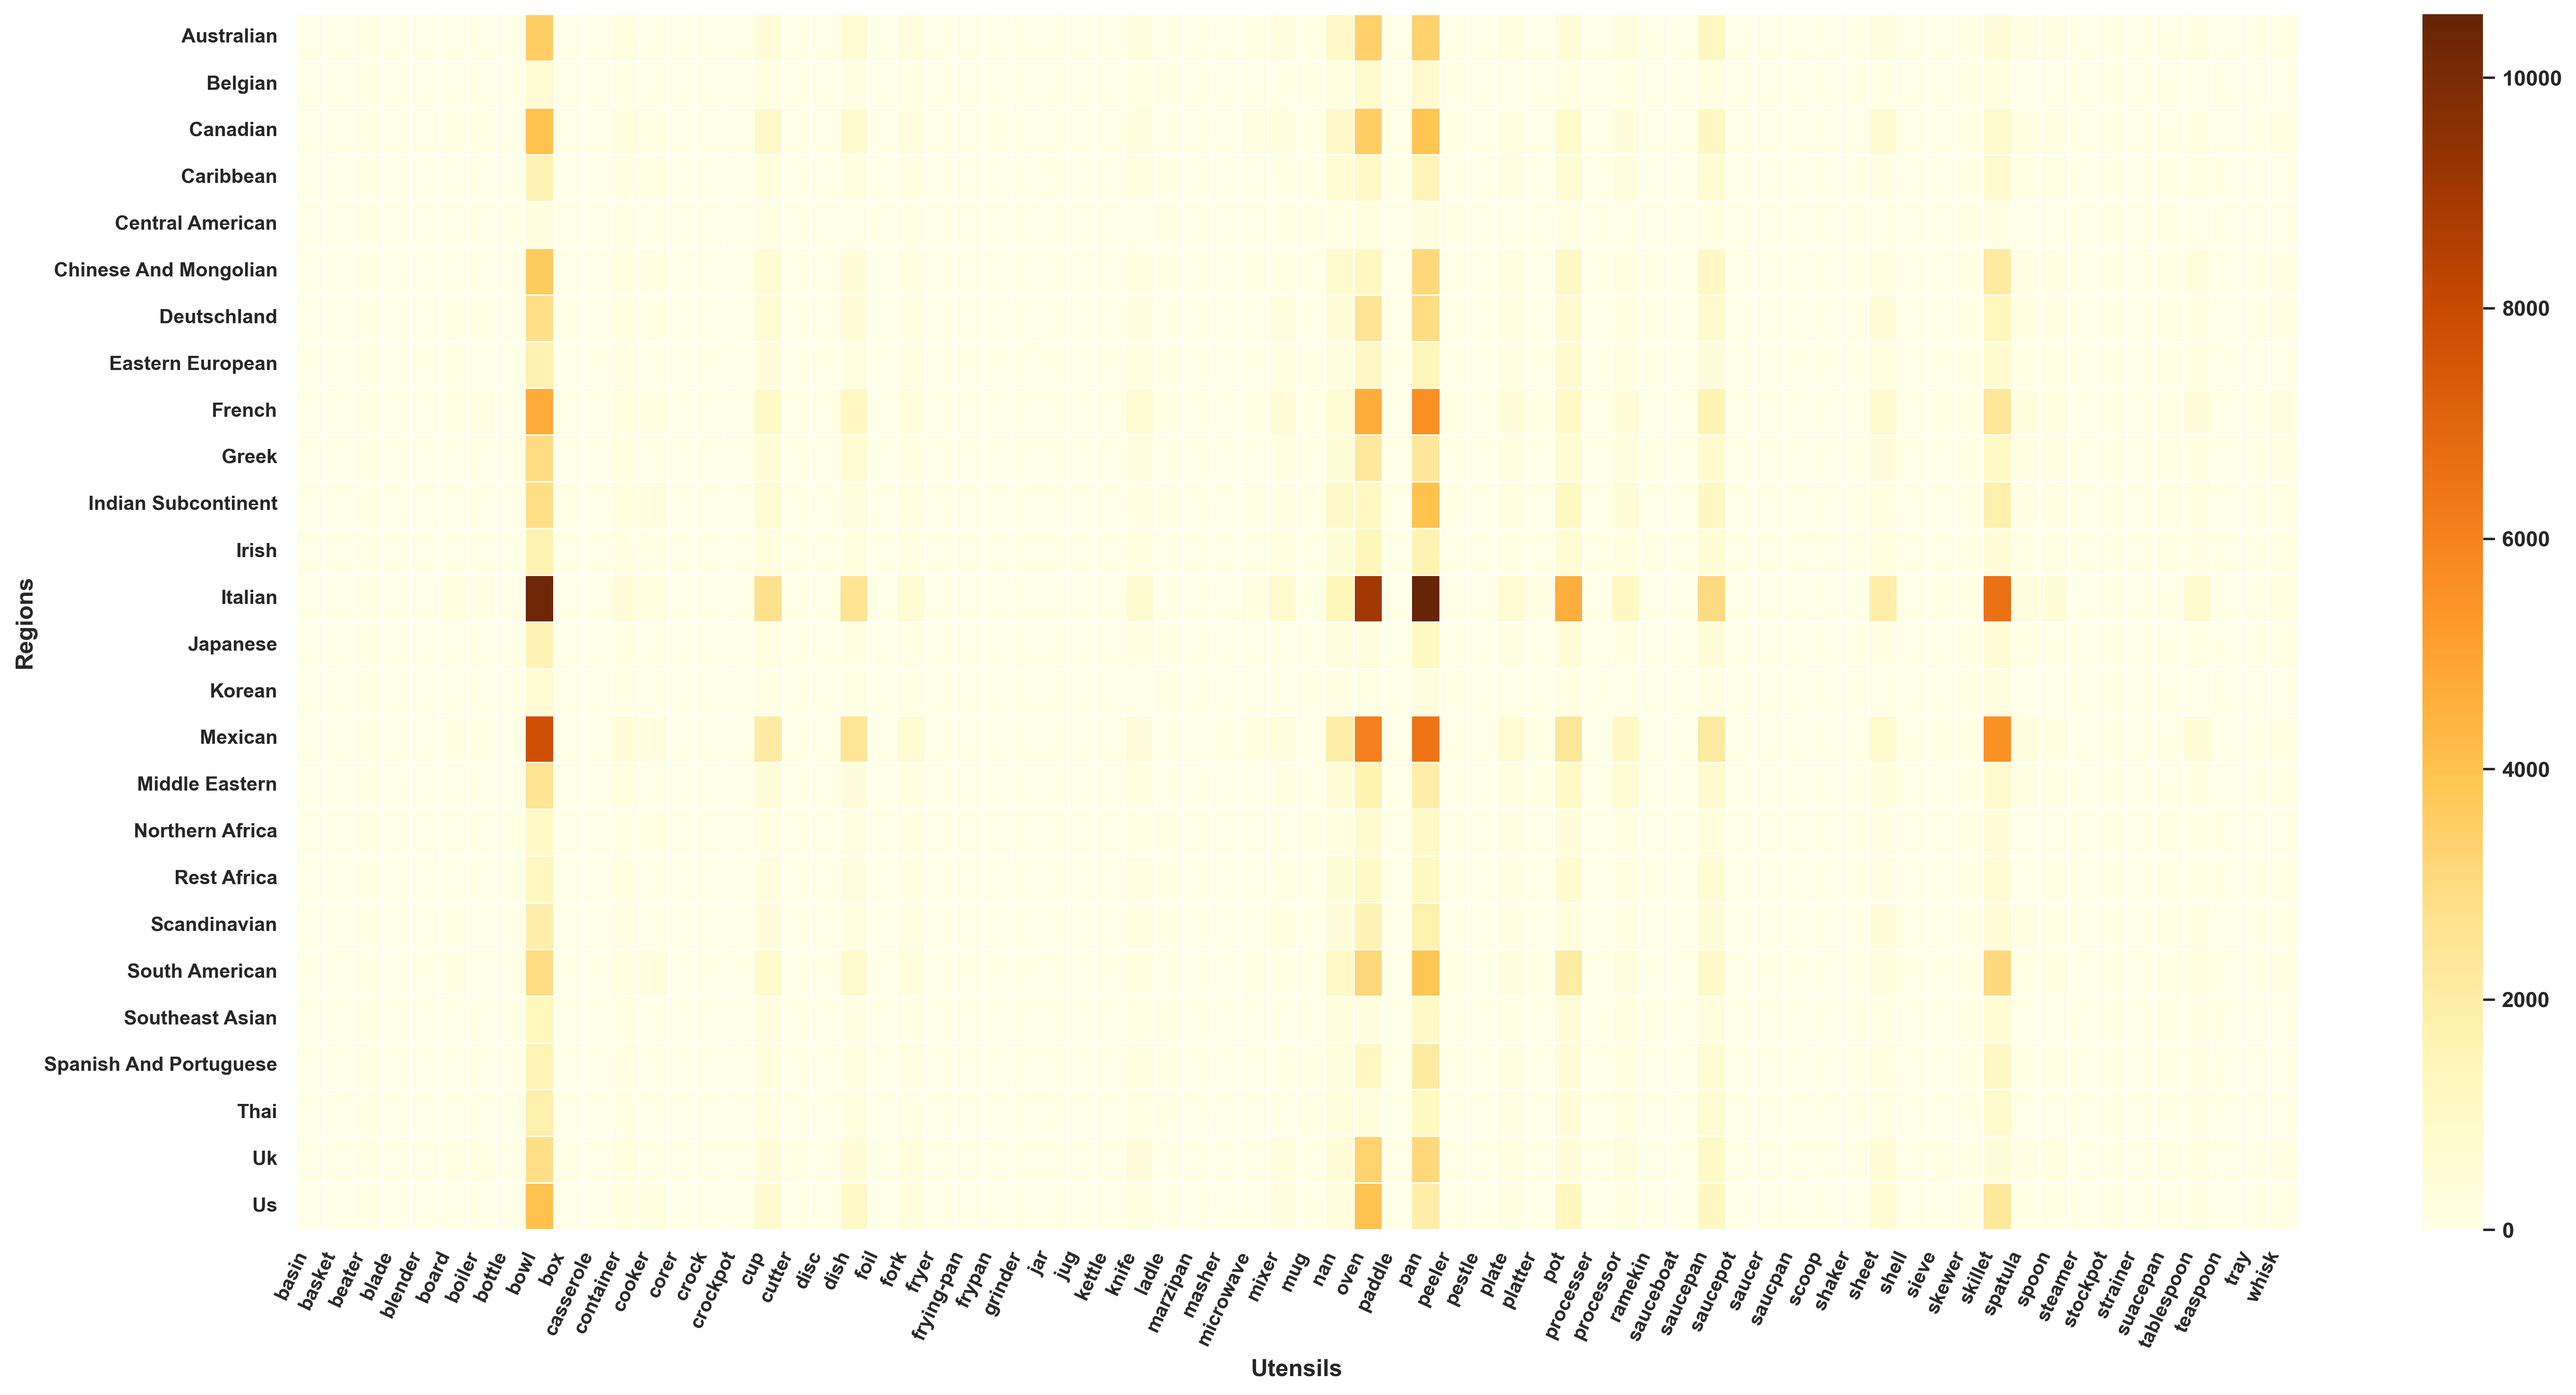

✅ Heatmap saved successfully


In [163]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors

# =========================
# 🎨 Style
# =========================
sns.set_theme(style="white")

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'

# =========================
# 📂 Load data
# =========================
file_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Region_utensil.csv"
df = pd.read_csv(file_path)

# =========================
# 🧹 Clean column names
# =========================
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
)

print("Columns found:", df.columns.tolist())

# =========================
# 🔥 EXPECTED COLUMNS
# =========================
# region, utensils
df = df.rename(columns={
    'utensils': 'utensils'
})

# =========================
# 🧹 Clean region
# =========================
df['region'] = df['region'].astype(str).str.strip().str.title()

# =========================
# 🧹 Split utensils (|| format)
# =========================
df['utensils_list'] = df['utensils'].astype(str).str.lower().str.split(r'\|\|')

df['utensils_list'] = df['utensils_list'].apply(
    lambda x: [i.strip() for i in x if i and i.strip() != '']
)

# =========================
# 🔥 EXPLODE
# =========================
df_exploded = df.explode('utensils_list')

df_exploded = df_exploded.dropna(subset=['region', 'utensils_list'])

# =========================
# 📊 PIVOT TABLE
# =========================
pivot_table = df_exploded.pivot_table(
    index='region',
    columns='utensils_list',
    aggfunc='size',
    fill_value=0
)

# =========================
# 📊 HEATMAP
# =========================
plt.figure(figsize=(20, 10), dpi=300)

sns.heatmap(
    pivot_table,
    cmap='YlOrBr',
    linewidths=0.3
)

# =========================
# 🏷 Labels
# =========================
plt.xlabel("Utensils", fontweight='bold', fontsize=12)
plt.ylabel("Regions", fontweight='bold', fontsize=12)

plt.xticks(rotation=65, ha='right', fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')

# =========================
# 📐 Layout
# =========================
plt.subplots_adjust(bottom=0.3)
plt.tight_layout()

# =========================
# 💾 Save
# =========================
plt.savefig(
    "Region_Utensil_Heatmap.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Heatmap saved successfully")

Columns found: ['region', 'servings']


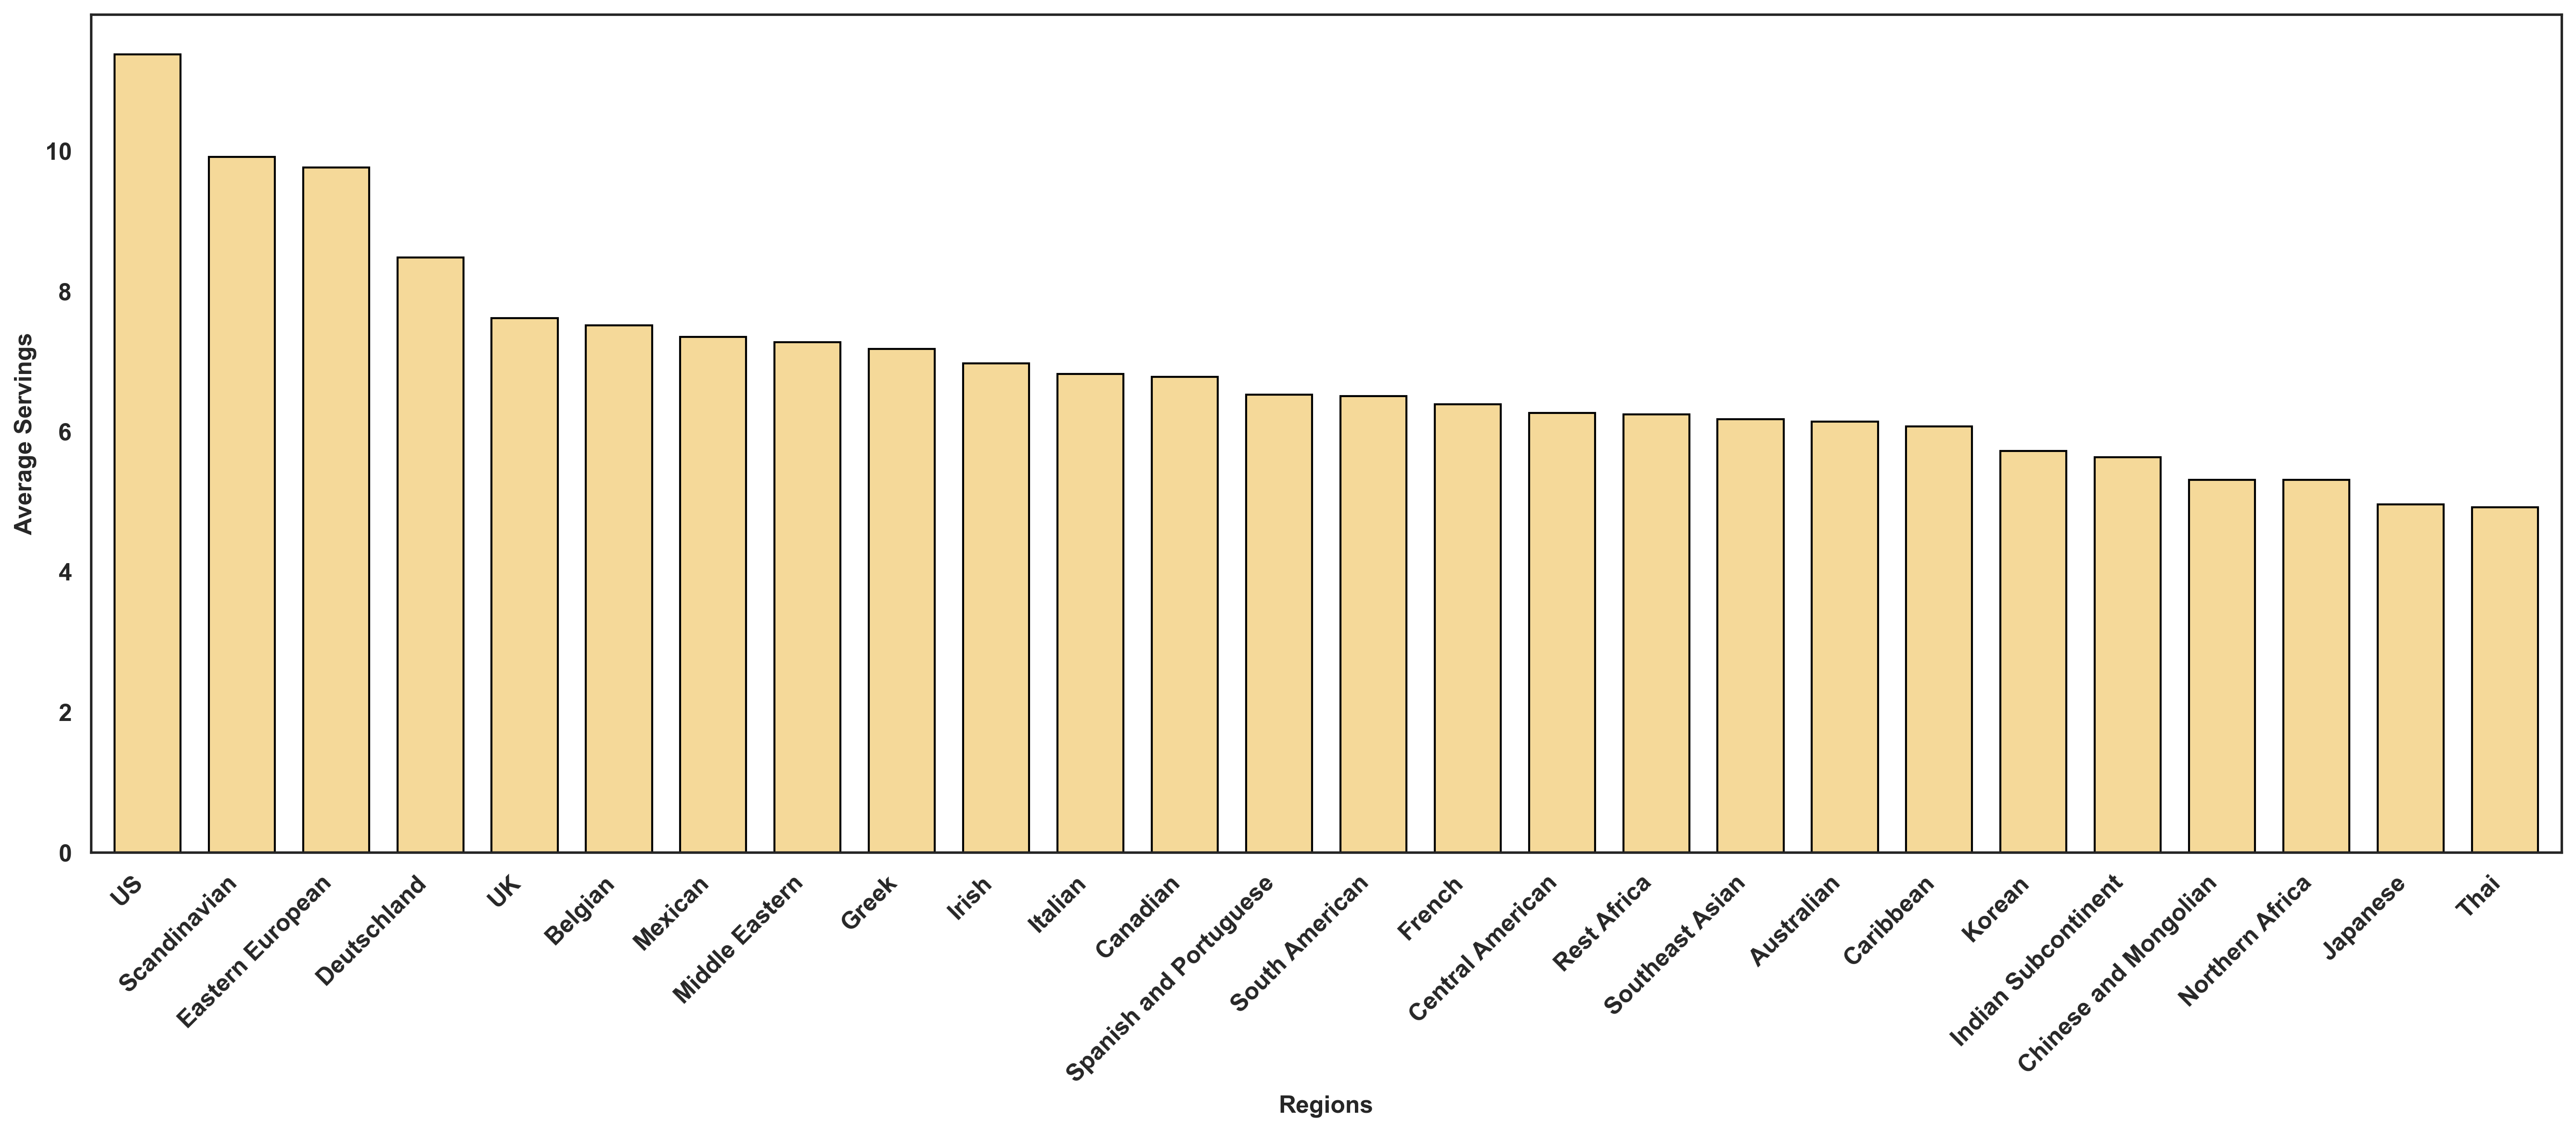

✅ Plot saved successfully


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors

# =========================
# 🎨 Function to lighten color
# =========================
def lighten_color(color, amount=0.6):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - np.array(c)) * (1 - amount))

# =========================
# 📂 Load data
# =========================
file_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Region_serving.csv"
df = pd.read_csv(file_path)

# =========================
# 🧹 Clean column names
# =========================
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
)

print("Columns found:", df.columns.tolist())

# =========================
# 🧹 Clean data (FIXED REGION HANDLING)
# =========================
df = df.dropna(subset=['region', 'servings'])

df['region'] = df['region'].astype(str).str.strip()

# 🔥 FIX: keep US and UK uppercase
df['region'] = df['region'].replace({
    "Us": "US",
    "Uk": "UK",
    "us": "US",
    "uk": "UK"
})

df['servings'] = pd.to_numeric(df['servings'], errors='coerce')
df = df.dropna(subset=['servings'])

# =========================
# 📊 Compute average servings
# =========================
avg_servings = (
    df.groupby('region')['servings']
    .mean()
    .sort_values(ascending=False)
)

# =========================
# 🎨 Style settings
# =========================
sns.set_theme(style="white")

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'

# =========================
# 🎨 Color
# =========================
base_color = '#E69F00'
light_color = lighten_color(base_color, 0.6)

# =========================
# 📊 Plot
# =========================
plt.figure(figsize=(18, 8), dpi=300)

avg_servings.plot(
    kind='bar',
    color=light_color,
    edgecolor='black',
    width=0.7
)

# =========================
# 🏷 Labels
# =========================
plt.xlabel("Regions", fontsize=12, fontweight='bold', fontname='Arial')
plt.ylabel("Average Servings", fontsize=12, fontweight='bold', fontname='Arial')

# =========================
# 📏 Ticks
# =========================
plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold', fontname='Arial')
plt.yticks(fontsize=12, fontweight='bold', fontname='Arial')

# =========================
# 🧼 Clean look
# =========================
plt.grid(False)

# =========================
# 💾 Save
# =========================
plt.tight_layout()

plt.savefig(
    "avg_servings_by_region_Arial_Bold.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Plot saved successfully")

Columns found: ['region', 'total_time']


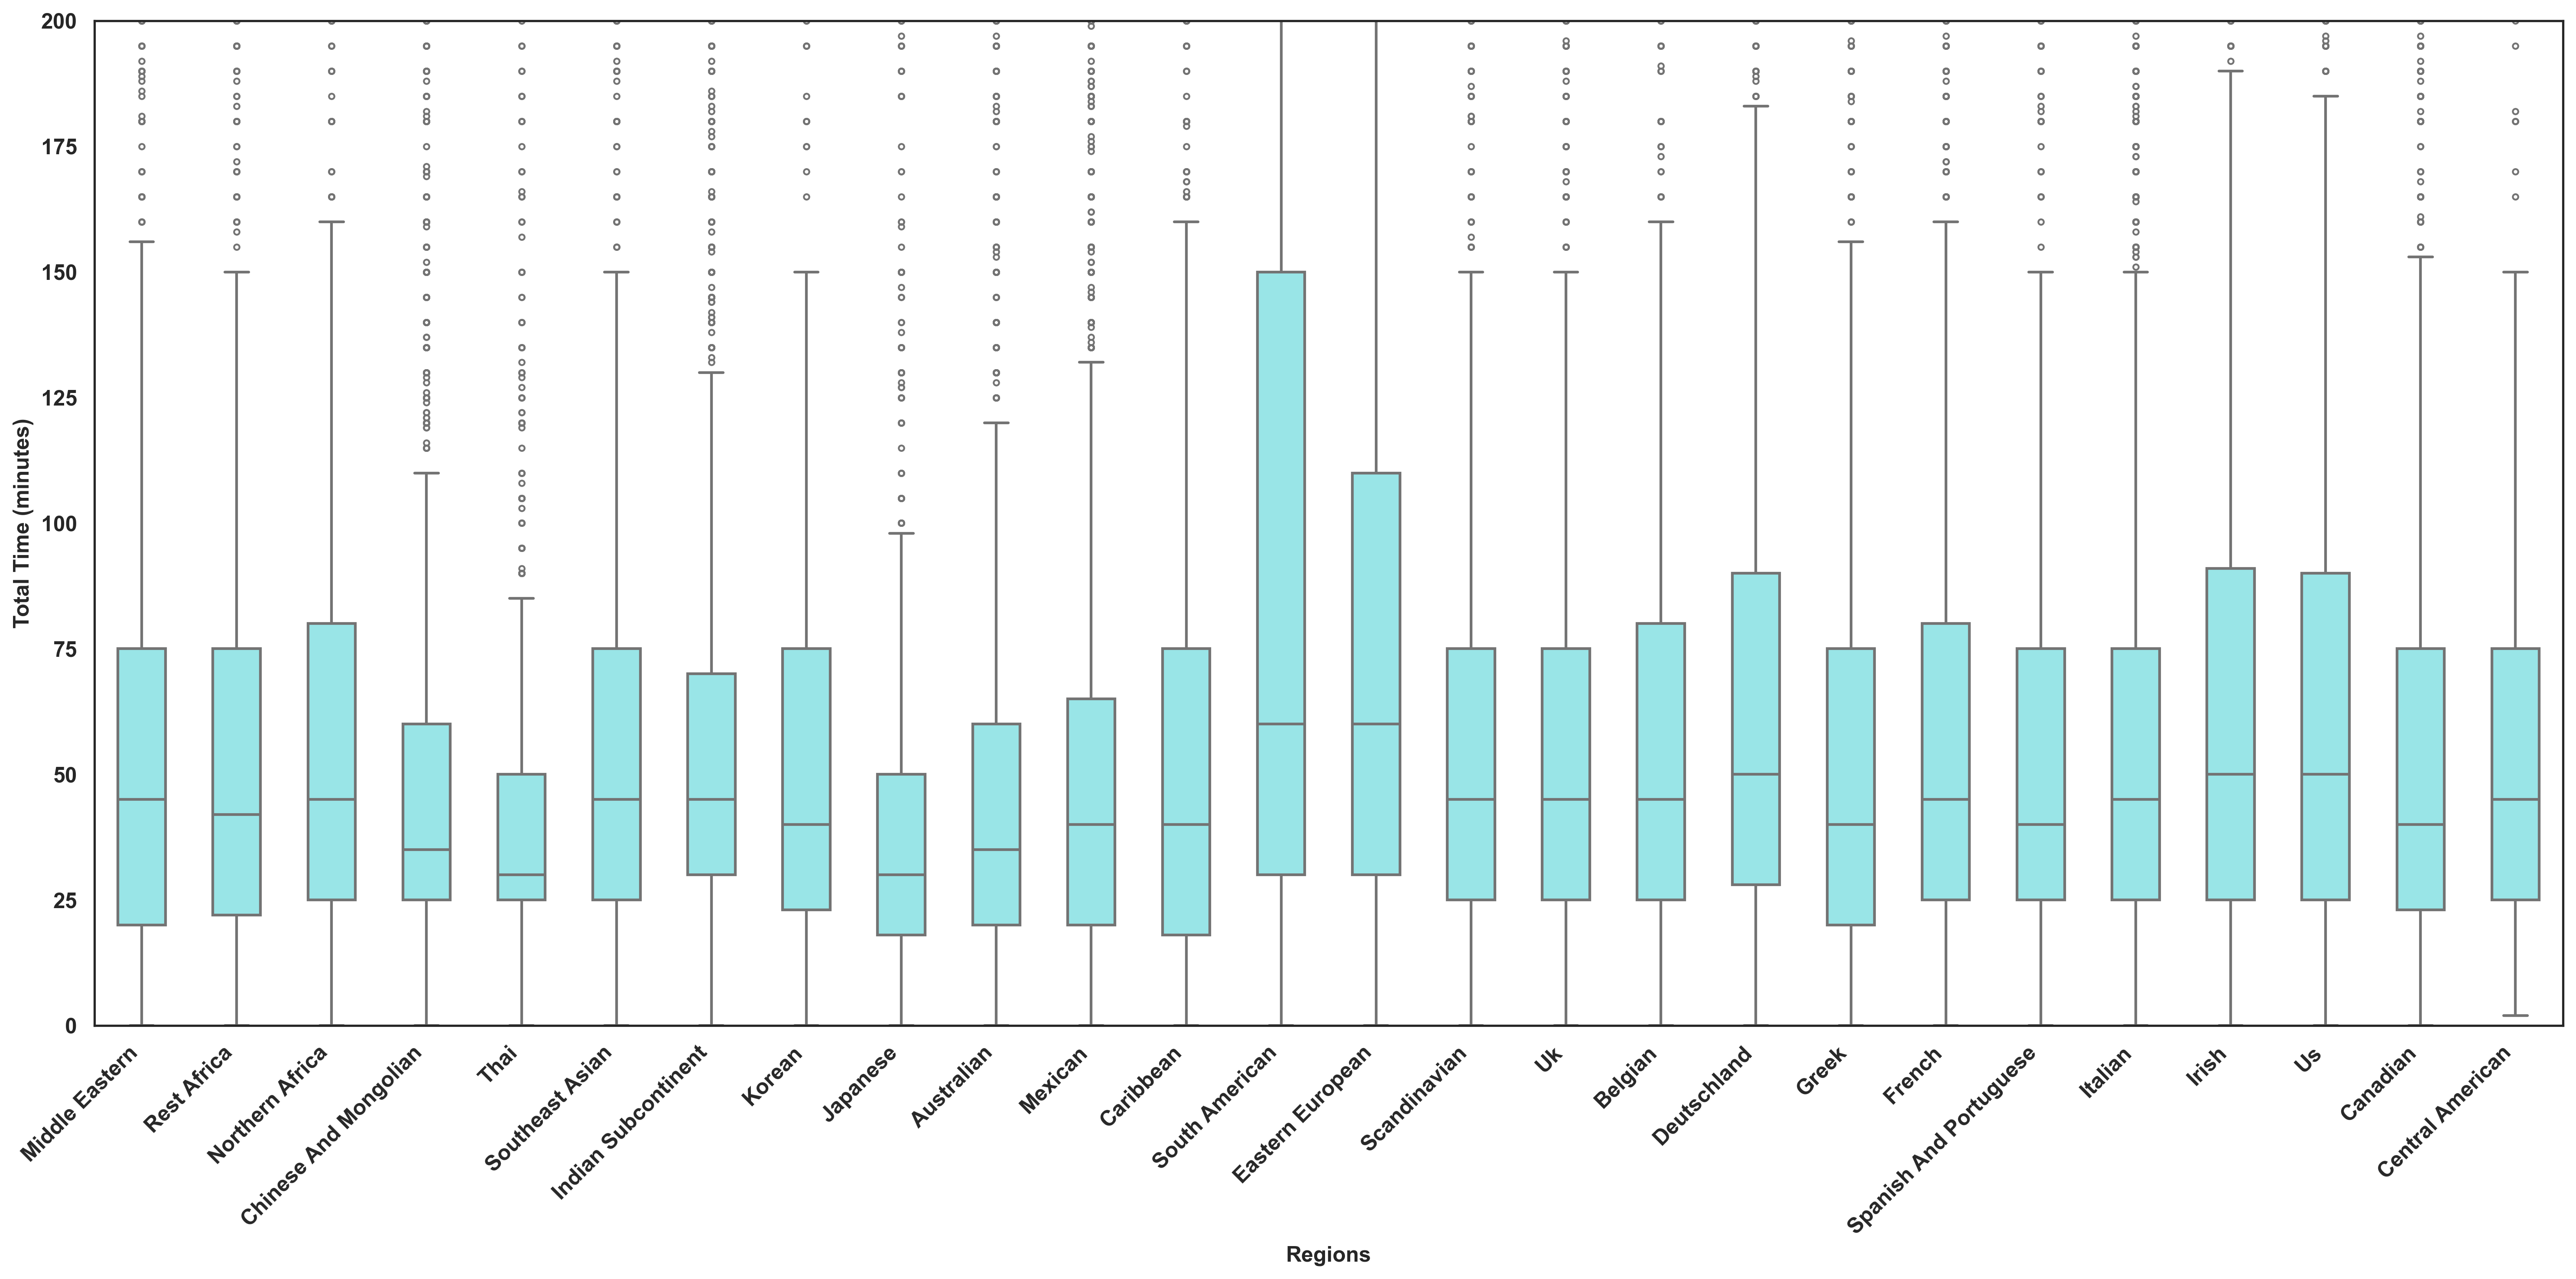

✅ Plot saved successfully


In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.colors as mcolors

# =========================
# 🎨 Function to lighten color
# =========================
def lighten_color(color, amount=0.6):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - np.array(c)) * (1 - amount))

# =========================
# 📂 Load data
# =========================
file_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Region_total_time.csv"
df = pd.read_csv(file_path)

# =========================
# 🧹 Clean columns
# =========================
df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.lower()
)

print("Columns found:", df.columns.tolist())

# =========================
# 🧹 Clean data
# =========================
df = df.dropna(subset=['region', 'total_time'])

df['region'] = df['region'].astype(str).str.strip().str.title()
df['total_time'] = pd.to_numeric(df['total_time'], errors='coerce')

df = df.dropna(subset=['total_time'])

# =========================
# 🎨 Theme & Fonts
# =========================
sns.set_theme(style="white")

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'

# =========================
# 🎨 Light color
# =========================
base_color = "#00BFC4"
light_color = lighten_color(base_color, 0.6)

# =========================
# 📊 Plot
# =========================
plt.figure(figsize=(20, 10), dpi=300)

sns.boxplot(
    x='region',
    y='total_time',
    data=df,
    width=0.5,
    linewidth=1.5,
    fliersize=3,
    color=light_color,
    saturation=1
)

# =========================
# 🚫 Grid off
# =========================
plt.grid(False)

# =========================
# 🏷 Labels
# =========================
plt.xlabel("Regions", fontsize=12, fontweight='bold', fontname='Arial')
plt.ylabel("Total Time (minutes)", fontsize=12, fontweight='bold', fontname='Arial')

# =========================
# 📏 Axis limit (optional safe check)
# =========================
max_val = df['total_time'].max()
plt.ylim(0, min(200, max_val + 10))

# =========================
# 📐 Tick formatting
# =========================
plt.xticks(rotation=45, ha='right', fontsize=12, fontweight='bold', fontname='Arial')
plt.yticks(fontsize=12, fontweight='bold', fontname='Arial')

# =========================
# 💾 Save
# =========================
plt.tight_layout()

plt.savefig(
    "Total_time_by_Region_Boxplot_Arial_Bold.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Plot saved successfully")

Columns found: ['total_time']


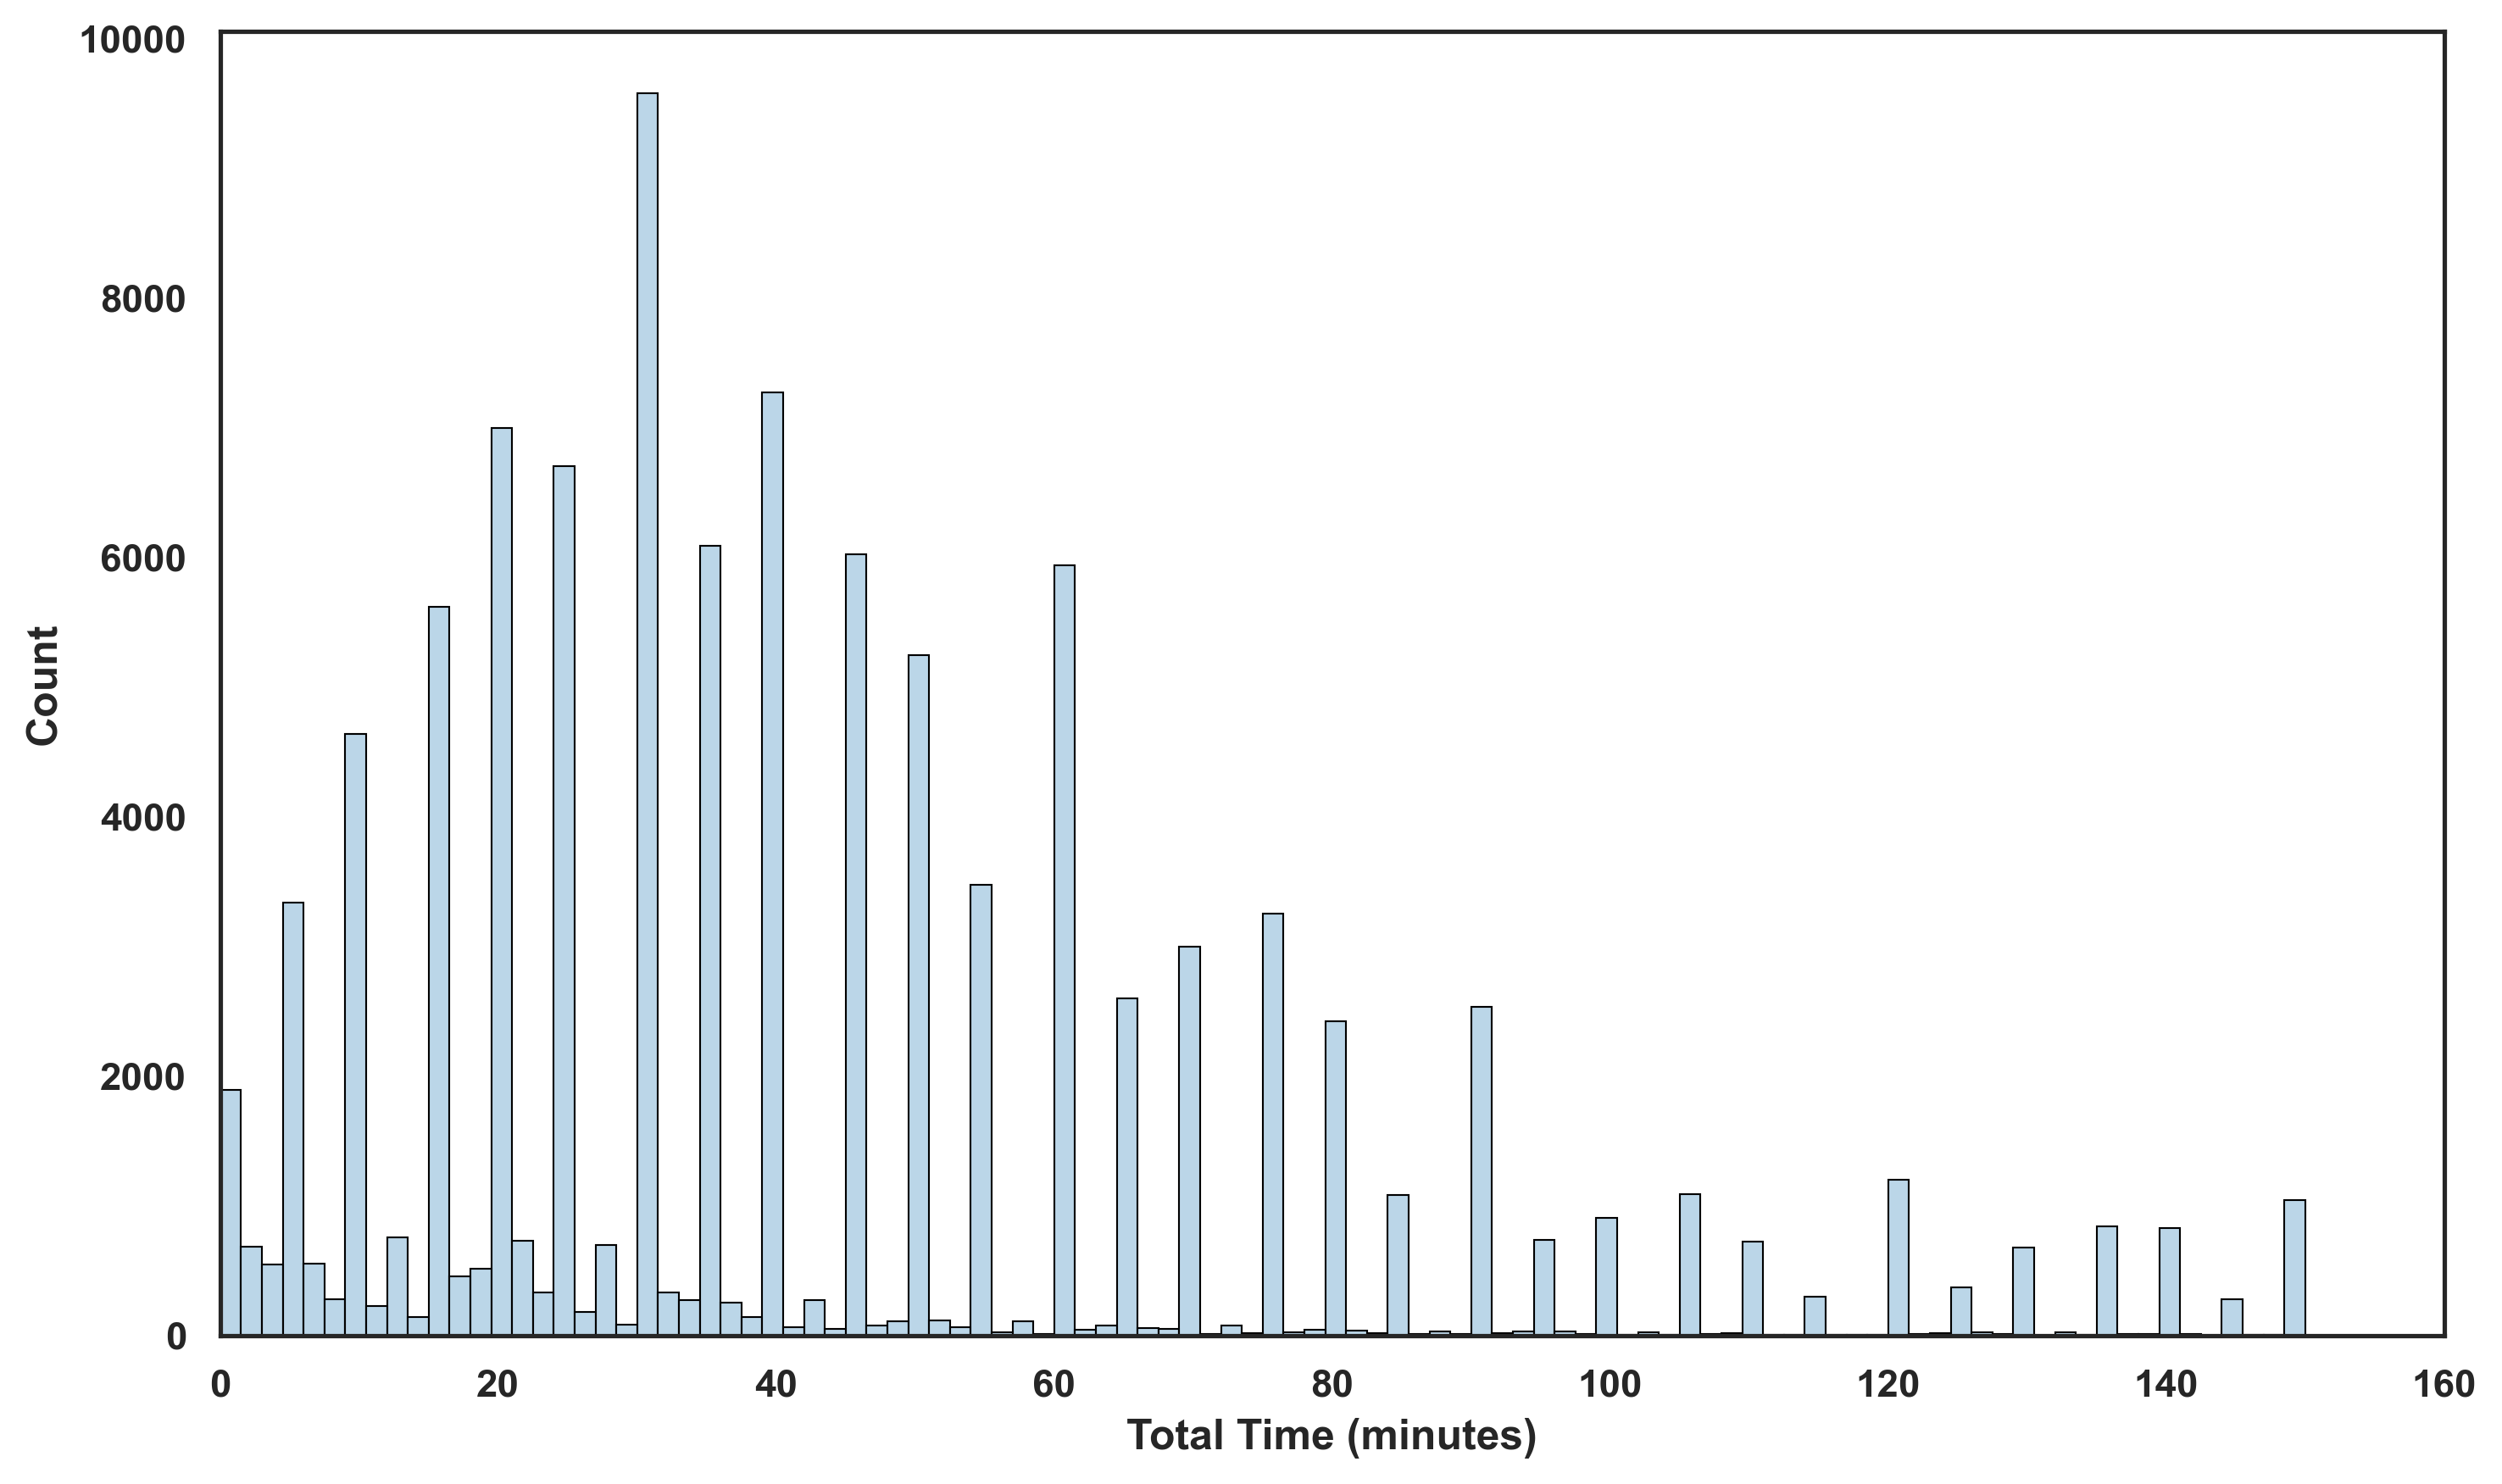

✅ Histogram saved successfully


In [169]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# =========================
# 🎨 Lighten color function
# =========================
def lighten_color(color, amount=0.6):
    c = mcolors.to_rgb(color)
    return tuple(1 - (1 - np.array(c)) * (1 - amount))

# =========================
# 📂 Load data
# =========================
file_path = r"C:/Users/madhu/Desktop/RecipeDB1_Updated_Code_Git/Total_time.csv"
df = pd.read_csv(file_path)

# =========================
# 🧹 Clean columns
# =========================
df.columns = df.columns.str.strip().str.lower()

print("Columns found:", df.columns.tolist())

# ensure numeric
df['total_time'] = pd.to_numeric(df['total_time'], errors='coerce')
df = df.dropna(subset=['total_time'])

# =========================
# 📊 Outlier removal (IQR method)
# =========================
Q1 = df['total_time'].quantile(0.25)
Q3 = df['total_time'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_filtered = df[
    (df['total_time'] >= lower_bound) &
    (df['total_time'] <= upper_bound)
]

# =========================
# 🎨 Color
# =========================
base_color = "#1f77b4"
light_color = lighten_color(base_color, 0.6)

# =========================
# 🎨 Style
# =========================
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'bold'

# =========================
# 📊 Plot
# =========================
plt.figure(figsize=(10, 6), dpi=300)

sns.histplot(
    df_filtered['total_time'],
    bins=100,
    color=light_color,
    edgecolor='black'
)

# =========================
# 📏 Axis settings
# =========================
plt.xlim(0, 160)
plt.ylim(bottom=0)

# =========================
# 🏷 Labels
# =========================
plt.xlabel("Total Time (minutes)", fontweight='bold', fontsize=12)
plt.ylabel("Count", fontweight='bold', fontsize=12)

# =========================
# 🧼 Clean look
# =========================
plt.grid(False)

plt.tight_layout()

# =========================
# 💾 Save
# =========================
plt.savefig(
    "Total_time_histogram_IQR_filtered.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("✅ Histogram saved successfully")